In [1]:
from util import *

directory = '/data/home/xiong/data/Fund/CSR/Traction-archieve/output/'

# set colors
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

cmap = plt.get_cmap('RdBu')  #RdYlBu
colors11 = [cmap(i/12) for i in range(11,0,-1)]
colors7 = [cmap(i/8) for i in range(7,0,-1)]
colors6 = [cmap(i/7) for i in range(6,0,-1)]
colors3 = [cmap(i/4) for i in range(3,0,-1)]

cmap = plt.get_cmap('Paired')
colors_cate = [cmap(i) for i in range(12)]
colors_cate = [colors_cate[i + 1] if i % 2 == 0 else colors_cate[i - 1] for i in range(len(colors_cate))]

#%matplotlib notebook

[nltk_data] Downloading package punkt to /data/home/xiong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Read data

In [2]:
df = pd.read_csv(directory + 'df_fin_reg.csv')  # df: containing rows with macro data but no AIV reports
df_documents = df[df['Print ISBN'].notna()]   # df_documents: containing rows with AIV reports
df_mon = pd.read_csv(directory+'gpt/df_documents_sector_labelled_mon_v2.csv')

In [3]:
key_cols = ['agreement_gpt',
 'agreement_gpt_Monetary',
 'agreement_gpt_Fiscal',
 'agreement_gpt_External',
 'agreement_gpt_Financial',
 'agreement_gpt_Real',
 'mon_agreement_gpt_ft', 'mon_agreement_stance_future_gpt_ft_num', 'mon_agreement_general_gpt_ft',
'fis_agreement_gpt_ft', 'fis_agreement_stance_near_term_gpt_ft_num', 'fis_agreement_general_gpt_ft']

In [4]:
for col in key_cols:
    print(df[col].value_counts())
    print('\n')

agreement_gpt
 4.0    777
 3.0    155
 2.0     30
 1.0      8
 5.0      4
-3.0      3
-2.0      3
-1.0      1
Name: count, dtype: int64


agreement_gpt_Monetary
 4.0    364
 5.0    199
 3.0     98
 2.0     18
 1.0     17
-2.0      6
-3.0      6
-4.0      1
-5.0      1
Name: count, dtype: int64


agreement_gpt_Fiscal
 4.0    514
 3.0    197
 5.0    161
 2.0     65
 1.0     25
-2.0      8
-4.0      5
-3.0      4
-1.0      1
 0.0      1
Name: count, dtype: int64


agreement_gpt_External
 4.0    493
 3.0    171
 5.0    146
 2.0     53
 1.0     20
-3.0     11
-2.0      5
-1.0      4
 0.0      2
Name: count, dtype: int64


agreement_gpt_Financial
 4.0    603
 5.0    210
 3.0    124
 2.0     23
 1.0      8
-2.0      4
-1.0      3
 0.0      3
-3.0      2
Name: count, dtype: int64


agreement_gpt_Real
 4.0    621
 3.0    156
 5.0    148
 2.0     35
 1.0     10
-4.0      2
-1.0      2
-2.0      1
 0.0      1
-3.0      1
Name: count, dtype: int64


mon_agreement_gpt_ft
1.0    571
0.0     79
Name:

In [5]:
df[df.duplicated(subset=['country','year'], keep=False)]

,index,Print ISBN,publication_date,filename_staff,filename_buff,buff_verified,staff_verified,"Extract text after "":""",Full Title,Subtitle,...,fis_stance_near_term_gpt_ft_buff_num,fis_agreement_stance_near_term_gpt_ft_num,fis_agreement_stance_near_term_gpt_ft_cate1,fis_agreement_stance_near_term_gpt_ft_cate2,fis_agreement_stance_near_term_gpt_ft,fis_agreement_general_gpt_ft,fis_disagreement_areas_general_gpt_ft,policy_mix_staff,policy_mix_buff,disagree_economic


Analysis

In [6]:
# df = df[(df['staff_verified']==True)]
df['year'] = df['year'].apply(lambda x: int(x) if x==x else np.nan)
df['Classification'] = df['Classification'].apply(lambda x: 'LICs' if x=='LIC' else x)

Text(0.5, 1.0, 'Number of Article IV Reports by Year')

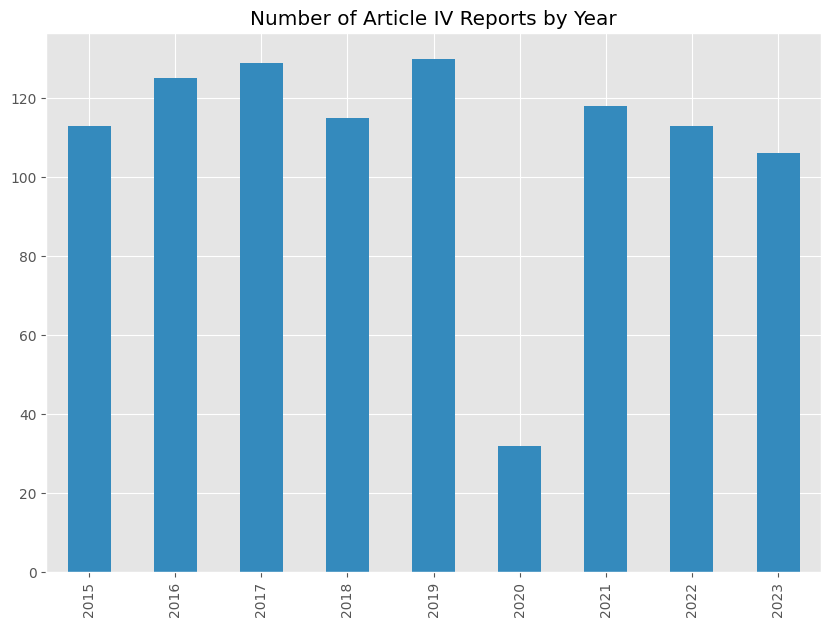

In [7]:
df[(df['staff_verified']==True)]['year'].apply(lambda x: int(x)).value_counts().sort_index().plot.bar(color=colors[1])
plt.xlabel('')
plt.title('Number of Article IV Reports by Year')

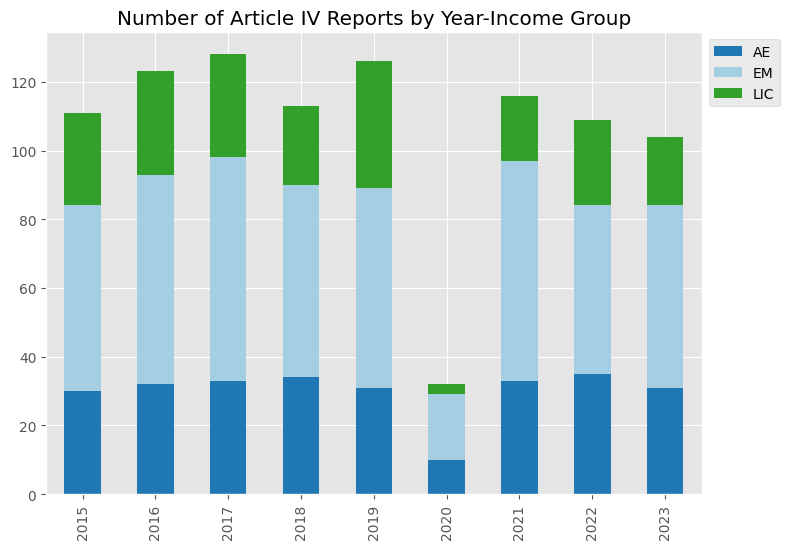

In [12]:
plt.rcParams['figure.figsize'] = (8,5.6)
df_temp = df[(df['staff_verified']==True)].groupby(['Classification', 'year']).count()['country'].reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['Classification'], values='country').fillna(0)
ax = pivot.plot.bar(stacked=True, color=colors_cate)
ax.set_title('Number of Article IV Reports by Year-Income Group')
plt.legend(['AE', 'EM', 'LIC'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

In [13]:
len(df[(df['staff_verified']==True)]), len(df[(df['staff_verified']==True)&(df['monetary_sample']==True)]), len(df_mon)

(981, 748, 686)

zero-shot

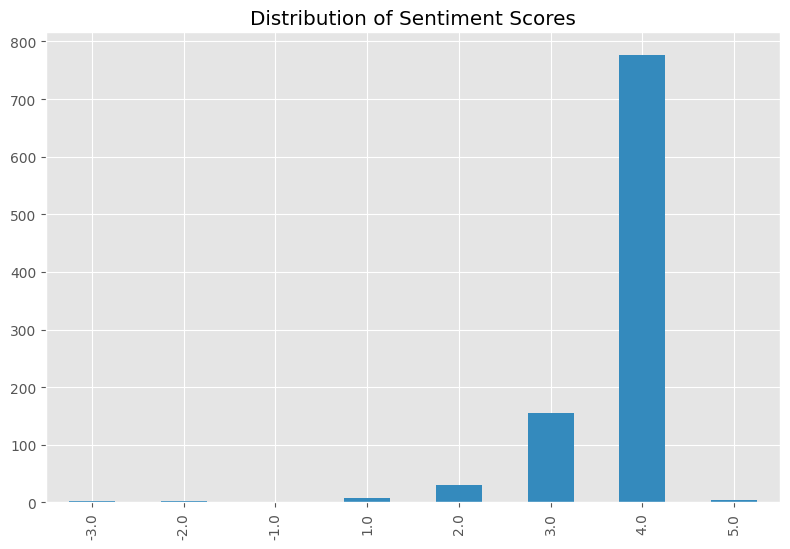

In [14]:
df_documents['agreement_gpt'].value_counts().sort_index().plot.bar(color=colors[1])
plt.xlabel('')
plt.title('Distribution of Sentiment Scores')
plt.tight_layout()

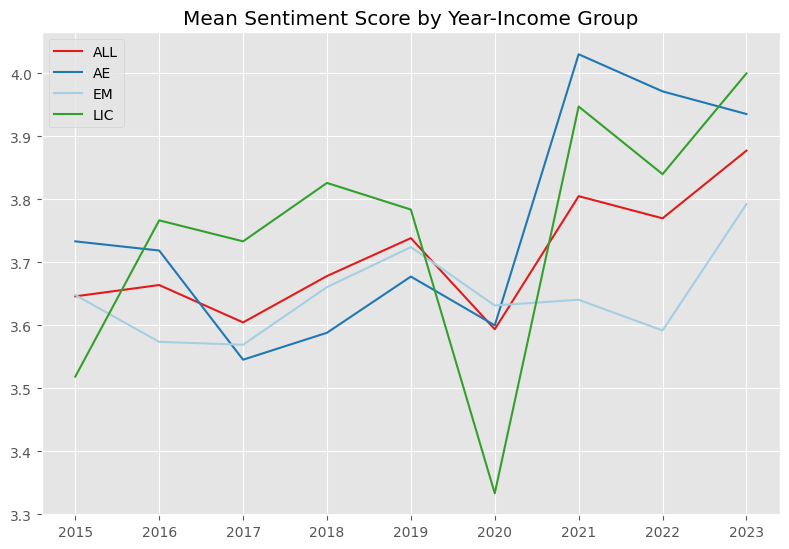

In [15]:
fig, ax = plt.subplots()

df_documents.groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[4])
df_documents[df_documents['Classification']=='AEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[0])
df_documents[df_documents['Classification']=='EMDEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[1])
df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[2])

# y = df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt'].mean().values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Mean Sentiment Score by Year-Income Group')
plt.legend(['ALL', 'AE', 'EM', 'LIC'])
plt.xlabel('')
plt.tight_layout()

/tmp/ipykernel_1278734/3621783338.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='AEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[0])
/tmp/ipykernel_1278734/3621783338.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='EMDEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[1])
/tmp/ipykernel_1278734/3621783338.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[2])


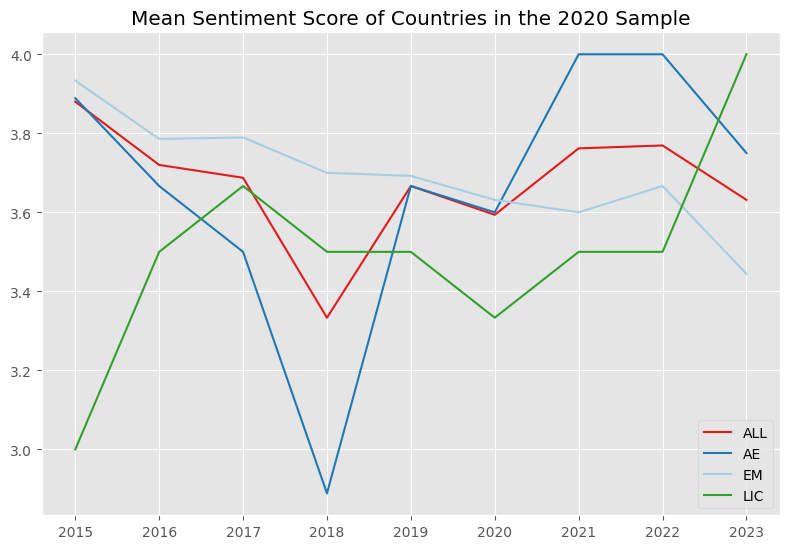

In [16]:
# sample selection bias?
country_subset = set(df_documents[df_documents['year']==2020]['country'])

fig, ax = plt.subplots()

df_documents[df_documents['country'].apply(lambda x: x in country_subset)].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[4])
df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='AEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[0])
df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='EMDEs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[1])
df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt'].mean().plot(color=colors_cate[2])

# y = df_documents[df_documents['country'].apply(lambda x: x in country_subset)][df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt'].mean().values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Mean Sentiment Score of Countries in the 2020 Sample')
plt.legend(['ALL', 'AE', 'EM', 'LIC'])
plt.xlabel('')
plt.tight_layout()

In [17]:
sectors = ['agreement_gpt_Monetary', 'agreement_gpt_Fiscal',
       'agreement_gpt_External', 'agreement_gpt_Financial',
       'agreement_gpt_Real']
for var in sectors:
    df_documents[var] = df_documents[var].apply(lambda x: np.nan if x==99 else x)

/tmp/ipykernel_1278734/2917545866.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_documents[var] = df_documents[var].apply(lambda x: np.nan if x==99 else x)


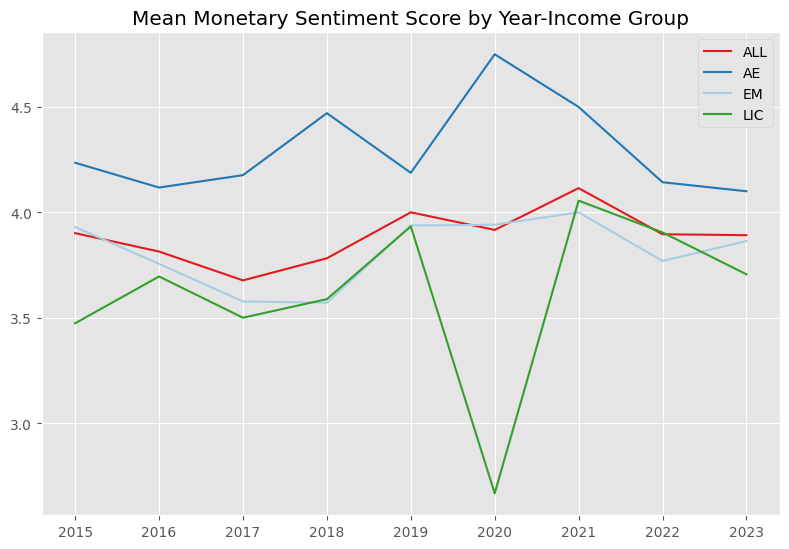

In [18]:
fig, ax = plt.subplots()

df_documents.groupby('year')['agreement_gpt_Monetary'].mean().plot(color=colors_cate[4])
df_documents[df_documents['Classification']=='AEs'].groupby('year')['agreement_gpt_Monetary'].mean().plot(color=colors_cate[0])
df_documents[df_documents['Classification']=='EMDEs'].groupby('year')['agreement_gpt_Monetary'].mean().plot(color=colors_cate[1])
df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt_Monetary'].mean().plot(color=colors_cate[2])

# y = df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt_Monetary'].mean().values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Mean Monetary Sentiment Score by Year-Income Group')
plt.legend(['ALL', 'AE', 'EM', 'LIC'])
plt.xlabel('')
plt.tight_layout()

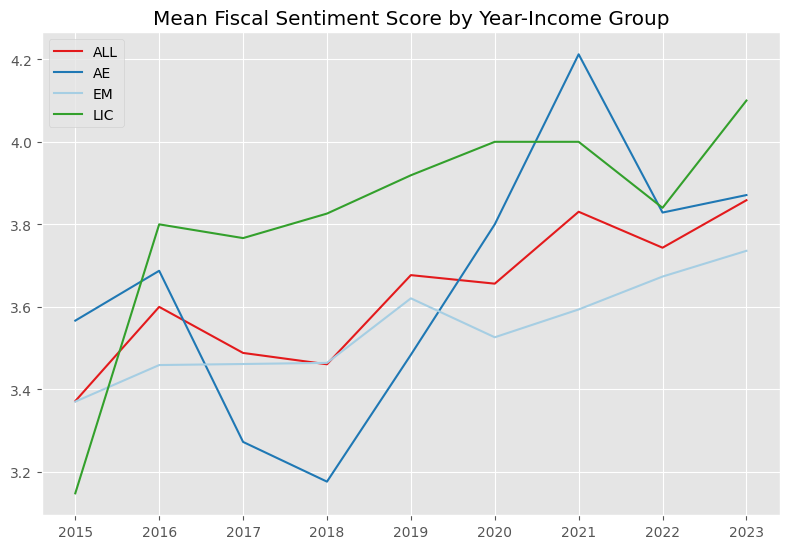

In [19]:
fig, ax = plt.subplots()

df_documents.groupby('year')['agreement_gpt_Fiscal'].mean().plot(color=colors_cate[4])
df_documents[df_documents['Classification']=='AEs'].groupby('year')['agreement_gpt_Fiscal'].mean().plot(color=colors_cate[0])
df_documents[df_documents['Classification']=='EMDEs'].groupby('year')['agreement_gpt_Fiscal'].mean().plot(color=colors_cate[1])
df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt_Fiscal'].mean().plot(color=colors_cate[2])

# y = df_documents[df_documents['Classification']=='LICs'].groupby('year')['agreement_gpt_Fiscal'].mean().values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Mean Fiscal Sentiment Score by Year-Income Group')
plt.legend(['ALL', 'AE', 'EM', 'LIC'])
plt.xlabel('')
plt.tight_layout()

In [20]:
df_documents['agreement_gpt_Monetary'].value_counts()

agreement_gpt_Monetary
 4.0    364
 5.0    199
 3.0     98
 2.0     18
 1.0     17
-2.0      6
-3.0      6
-4.0      1
-5.0      1
Name: count, dtype: int64

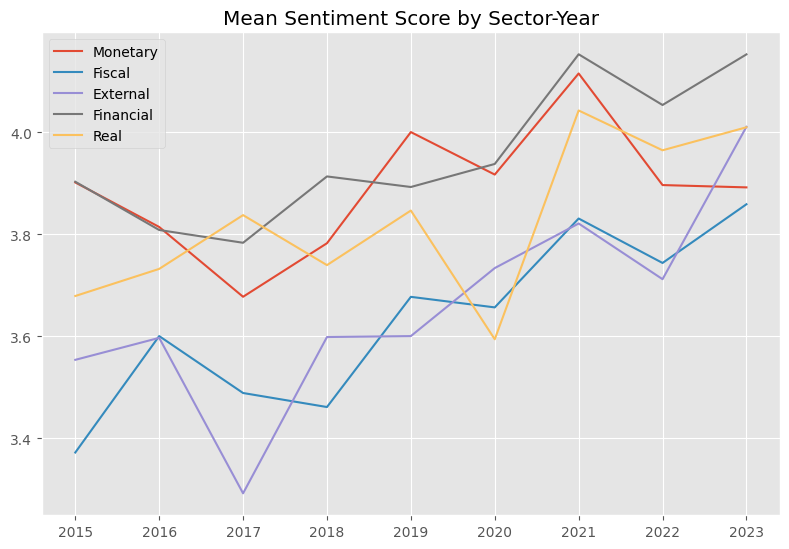

In [21]:
df_documents.rename(columns={c:c.replace('agreement_gpt_', '') for c in sectors}).groupby('year')[[c.replace('agreement_gpt_', '') for c in sectors]].mean().plot()
plt.title('Mean Sentiment Score by Sector-Year')
plt.xlabel('')
plt.tight_layout()

<Axes: >

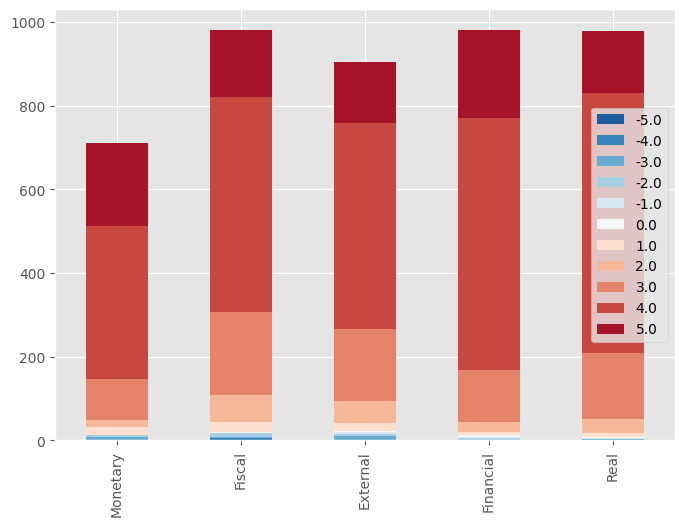

In [22]:
df_temp = pd.DataFrame([df_documents[var].value_counts() for var in sectors]).fillna(0)
df_temp.index = [s.replace('agreement_gpt_', '') for s in sectors]
df_temp[sorted(df_temp.columns)].plot.bar(stacked=True, color=colors11)

In [23]:
disagreement_cols = ['Monetary_gpt', 'Fiscal_gpt', 'External_gpt', 'Financial_gpt', 'Real_gpt', 'other_areas_gpt']
for col in disagreement_cols:
    df_documents[col] = df_documents[col].apply(lambda x: ast.literal_eval(x))

/tmp/ipykernel_1278734/1896278243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_documents[col] = df_documents[col].apply(lambda x: ast.literal_eval(x))


Text(0.5, 0, '')

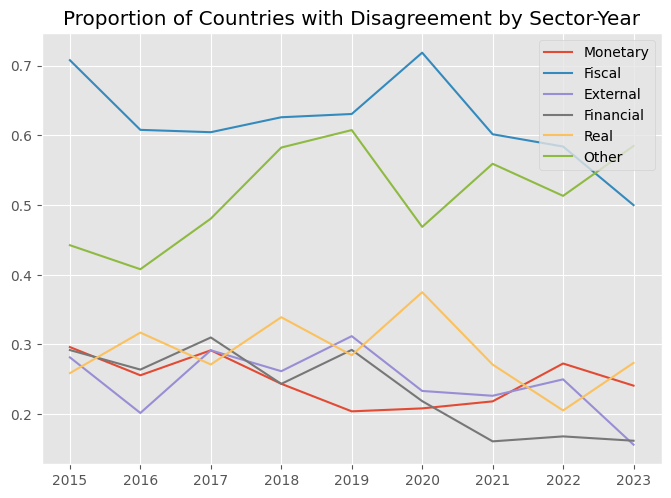

In [24]:
sectors = ['Monetary', 'Fiscal',
       'External', 'Financial',
       'Real']
for var in sectors:
    df_temp = df_documents[~df_documents['agreement_gpt_'+var].isna()]
    df_temp.set_index('year')[var+'_gpt'].apply(lambda x: len(x)>0 if type(x)==dict else 0).groupby(level=0).mean().plot()
df_documents.set_index('year')['other_areas_gpt'].apply(lambda x: len(x)>0 if type(x)==dict else 0).groupby(level=0).mean().plot()
plt.legend(sectors+['Other'], loc='upper right')
plt.title('Proportion of Countries with Disagreement by Sector-Year')
plt.xlabel('')

Text(0.5, 0, '')

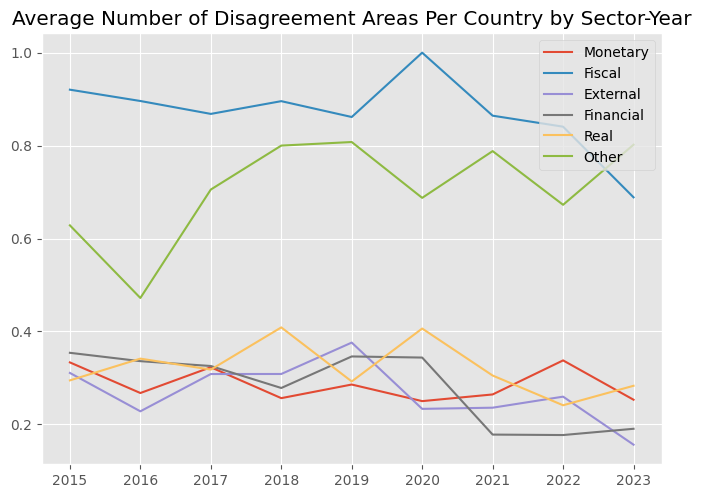

In [25]:
sectors = ['Monetary', 'Fiscal',
       'External', 'Financial',
       'Real']
for var in sectors:
    df_documents[~df_documents['agreement_gpt_'+var].isna()].set_index('year')[var+'_gpt'].apply(lambda x: len(x) if type(x)==dict else 0).groupby(level=0).mean().plot()
df_documents.set_index('year')['other_areas_gpt'].apply(lambda x: len(x) if type(x)==dict else 0).groupby(level=0).mean().plot()
plt.legend(sectors+['Other'], loc='upper right')
plt.title('Average Number of Disagreement Areas Per Country by Sector-Year')
plt.xlabel('')

In [26]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Monetary_gpt'].apply(lambda x: list(x.keys())))))[0].value_counts().index
field_dict = {
  "Monetary Policy Framework": [
    "monetary policy framework",
    "monetary policy effectiveness",
    "monetary policy transmission",
    "monetary policy synchronization",
    "monetary policy formulation",
    "monetary policy conditions",
    "monetary policy implementation",
    "monetary policy transition",
    "monetary policy framework transition",
    "monetary policy architecture"
  ],
  "Monetary Policy Direction": [
    "monetary policy",
    "monetary policy direction",
    "monetary policy stance",
    "monetary policy tightening",
    "monetary policy communication",
    "monetary policy focus",
    "monetary policy timing",
    "monetary policy response",
    "monetary policy normalization",
    "monetary policy perception",
    "monetary policy action timing",
    "monetary policy easing",
    "monetary policy response to supply shocks",
    "monetary policy tightening pace",
    "monetary policy normalization pace"
  ],
  "Monetary Policy Operations": [
    "monetary policy tools",
    "monetary policy tool rebalancing"
  ],
  "Foreign Exchange Policies": [
    "exchange rate flexibility",
    "exchange rate policy",
    "exchange rate management",
    "exchange rate liberalization",
    "exchange rate overvaluation",
    "exchange rate regime",
    "FX orders backlog size",
    "currency flexibility",
    "foreign exchange intervention transparency",
    "FX market development measures",
    "FX intervention transparency",
    "foreign exchange intervention",
    "Publication of FXI data",
    "exchange rate policy direction",
    "exchange rate framework",
    "exchange rate reform pace",
    "exchange rate and FXI assessments",
    "FX market interventions"
  ],
  "Inflation": [
    "inflation target range",
    "inflation management",
    "inflation outlook",
    "inflation target communication",
    "currency depreciation impact on inflation",
    "inflation persistence",
    "inflation targeting",
    "inflation reference rate",
    "inflation divergence",
    "inflation projections"
  ],
  "Interest Rate": [
    "interest rate cap",
    "interest rate policy",
    "negative interest rates",
    "real interest rates",
    "interest rate corridor",
    "interest rate caps",
    "interest rate controls"
  ],
  "Other": [
    "capital flow management measures",
    "BOM's balance sheet expansion",
    "BOM capital adequacy",
    "currency changeover risks",
    "credit growth ceilings",
    "capital flow management measure",
    "use of U.S. dollar-indexed CBL bills",
    "amendments to BoG Act",
    "reserve adequacy assessment",
    "output gap assessment",
    "central bank independence",
    "climate change considerations",
    "currency reform"
  ]
}

Text(0.5, 1.0, 'Disagreement Areas - Monetary Sector')

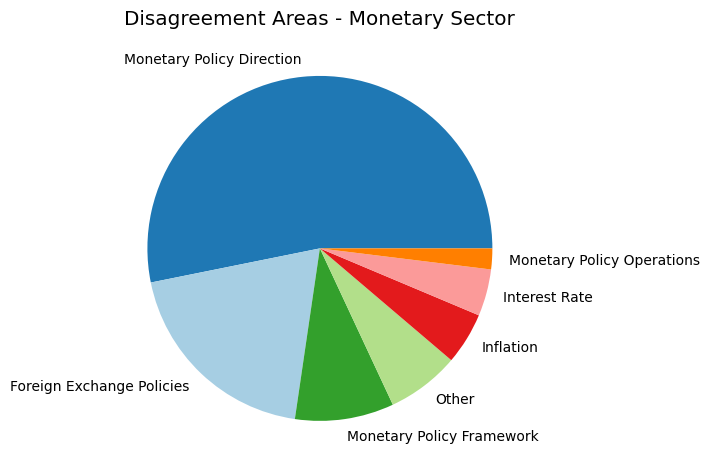

In [27]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Monetary_gpt'].apply(lambda x: list(x.keys())))))[0].apply(lambda x: x if x in ['monetary policy direction', 'monetary policy stance',
#        'exchange rate flexibility', 'monetary policy framework',
#        'exchange rate policy', 'exchange rate management',
#        'monetary policy tightening', 'monetary policy tools',
#        'monetary policy communication'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Monetary_gpt'].apply(lambda x: list(x.keys())))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)
plt.ylabel('')
plt.title('Disagreement Areas - Monetary Sector')

In [28]:
# list(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Fiscal_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index)

field_dict = {
  "Fiscal Consolidation and Adjustment": [
    "fiscal consolidation pace",
    "pace of fiscal consolidation",
    "fiscal adjustment pace",
    "fiscal consolidation",
    "fiscal consolidation approach",
    "fiscal consolidation timing",
    "fiscal consolidation measures",
    "fiscal consolidation strategy",
    "fiscal consolidation timeline",
    "fiscal consolidation path",
    "fiscal consolidation ambition",
    "fiscal adjustment strategy",
    "fiscal adjustment",
    "fiscal adjustment approach",
    "fiscal adjustment speed",
    "fiscal adjustment scale",
    "pace of fiscal adjustment",
    "pace of fiscal deficit reduction",
    "fiscal deficit reduction pace",
    "fiscal deficit reduction",
    "pace of debt reduction",
    "pace and composition of fiscal adjustment",
    "gradual fiscal consolidation",
    "fiscal consolidation efforts",
    "fiscal consolidation plan",
    "fiscal consolidation impact on growth",
    "fiscal consolidation necessity",
    "fiscal consolidation speed",
    "Timing of fiscal consolidation",
    "timing of fiscal adjustment",
    "timing of fiscal consolidation",
    "additional fiscal measures",
    "composition of fiscal adjustment",
    "fiscal adjustment measures",
    "fiscal balance improvement",
    "fiscal deficit management",
    "fiscal expansion",
    "fiscal path",
    "fiscal position assessment",
    "fiscal redistribution",
    "fiscal relief measures",
    "fiscal rule adherence",
    "fiscal sustainability measures",
    "fiscal target achievability",
    "fiscal targets",
    "fiscal targets achievability",
    "fiscal targets ambition",
    "fiscal targets and policy mix",
    "fiscal stance and spending prioritization",
    "size of fiscal adjustment",
    "operational target for fiscal adjustment",
    "fiscal adjustment urgency",
    "sufficiency of fiscal measures",
    "targeting of fiscal measures",
    "fiscal rule relaxation",
    "fiscal rule necessity",
    "fiscal rule complexity",
    "fiscal rule parameters",
    "specific fiscal rule",
    "fiscal rules legislation",
    "fiscal rules reform direction",
    "fiscal rule calibration",
    "fiscal rule adaptation",
    "timing of fiscal measures"
  ],
  "Tax Policy and Administration": [
    "tax policy",
    "tax exemptions",
    "tax policy measures",
    "tax reforms",
    "VAT exemptions",
    "tax system reform",
    "sectoral taxes",
    "VAT increase",
    "taxation strategy",
    "real estate tax",
    "mortgage interest deductibility",
    "VAT rates",
    "tax progressivity",
    "carbon taxation",
    "tax cuts",
    "tax credit",
    "tax mix adjustment",
    "tax policy changes",
    "tax policy review",
    "tax policy direction",
    "tax policy reform",
    "VAT structure",
    "VAT implementation",
    "VAT complexity",
    "VAT reform",
    "VAT revenue potential",
    "VAT implementation timeline",
    "VAT rate increase",
    "VAT rate cuts",
    "differentiated VAT rates",
    "GST rate alignment",
    "VAT introduction timing",
    "tax reform",
    "tax system reform",
    "tax administration",
    "tax administration reform",
    "tax administration improvements",
    "tax reform impact",
    "tax reform scope",
    "tax reform size",
    "tax reform balance",
    "tax reform implementation timeline",
    "taxation reform",
    "taxation challenges",
    "tax incentives effectiveness",
    "tax evasion focus",
    "tax incentive reform",
    "labor taxation",
    "social security taxation",
    "carbon tax approach",
    "carbon pricing",
    "pollution tax",
    "energy tax policy",
    "gasoline excise tax policy",
    "windfall tax",
    "energy price caps",
    "energy price cap",
    "energy subsidy policy",
    "energy subsidies reform",
    "energy subsidies adjustment",
    "energy subsidy reform",
    "fuel subsidy reform",
    "fuel subsidy removal",
    "pace of fuel subsidy removal",
    "fuel subsidies",
    "domestic fuel price adjustments",
    "automatic fuel pricing mechanism",
    "energy price policy",
    "energy price measures",
    "energy price impact",
    "energy support measures",
    "energy support targeting",
    "energy inflation compensation measures",
    "energy price caps",
    "removal of tax exemptions",
    "tax expenditure cuts",
    "introduction of personal income tax",
    "introduction of personal and corporate income taxes",
    "PIT regime reversal",
    "progressivity of PIT",
    "youth PIT exemption",
    "income tax cut",
    "immovable property tax",
    "property tax",
    "property tax increase",
    "real estate tax",
    "real estate tax feasibility",
    "social security contribution cuts",
    "use of generalized subsidies",
    "subsidy rationalization",
    "subsidy reduction",
    "subsidies and social spending",
    "CIT reform revenue neutrality",
    "tax policy impact",
    "tax reduction and fiscal buffers",
    "tax reduction plans",
    "tax relief measures",
    "tax system competitiveness",
    "tax system progressivity",
    "tax credits treatment"
  ],
  "Debt Management and Sustainability": [
    "debt sustainability",
    "external borrowing",
    "debt management",
    "debt management strategy",
    "debt brake rule",
    "debt reduction target",
    "debt reduction pace",
    "debt reduction challenges",
    "debt reduction feasibility",
    "debt anchor",
    "debt anchor necessity",
    "debt coverage",
    "debt classification",
    "debt law approval",
    "debt ceiling",
    "debt ceiling timing",
    "debt ceiling and fiscal uncertainty",
    "debt sustainability assessment",
    "debt sustainability analysis",
    "debt management and fiscal adjustment",
    "debt thresholds",
    "debt rule amendments",
    "debt stabilization strategy",
    "public debt ceiling",
    "public debt target",
    "public debt concerns",
    "coverage of public debt",
    "non-hydrocarbon deficit reduction",
    "oil price assumptions",
    "reliance on extractive revenues",
    "BOAD debt reclassification",
    "external balance consideration",
    "external borrowing",
    "CBI inflows reliance",
    "use of CBI revenue",
    "use of ECP revenues",
    "use of FSMTF as stabilizer",
    "use of FGF assets",
    "use of FHF for social assistance",
    "use of NSCs",
    "use of Petroleum Fund",
    "use of public savings",
    "use of Reserve Fund",
    "use of SOEs retained earnings",
    "Petrocaribe obligations inclusion",
    "excess withdrawals from Petroleum Fund",
    "net domestic financing ceiling",
    "fiscal deficit financing",
    "investment financing",
    "investment financing risks",
    "pre-financing as a tool",
    "BCB lending to SOEs",
    "bank recapitalization",
    "directed lending reduction",
    "KPST early withdrawals",
    "repayment of advances",
    "administration of funds outside treasury",
    "use of extra-budgetary funds",
    "SIDF integration into budget",
    "CDF spending",
    "CDF transparency",
    "debt target level",
    "debt/GDP ratio estimates",
    "defense expenditures and debt",
    "NSCs reliance",
    "non-hydrocarbons primary deficit",
    "need for additional savings",
    "use of fiscal reserves"
  ],
  "Public Spending and Investment": [
    "fiscal deficit projections",
    "fiscal deficit target",
    "fiscal deficit targets",
    "fiscal deficit size",
    "fiscal deficit concerns",
    "fiscal deficit impact on inflation",
    "fiscal deficit reduction",
    "fiscal deficit reduction pace",
    "fiscal deficit target timeline",
    "fiscal deficit and debt sustainability",
    "fiscal deficit flexibility",
    "fiscal deficit target achievability",
    "fiscal deficit reduction",
    "pace of fiscal deficit reduction",
    "augmented fiscal deficit and debt",
    "augmented deficit/debt concept",
    "augmented deficit and debt concept",
    "augmented debt and deficit concepts",
    "fiscal deficit target timing",
    "fiscal support level",
    "fiscal support size",
    "fiscal support duration",
    "fiscal support withdrawal pace",
    "additional fiscal support",
    "targeting of fiscal support",
    "fiscal support impact",
    "fiscal stimulus",
    "fiscal stimulus size",
    "fiscal stimulus scale",
    "fiscal stimulus timing",
    "fiscal stimulus approach",
    "fiscal stimulus impact",
    "fiscal stimulus measures",
    "composition of fiscal stimulus",
    "rules-based stimulus",
    "fiscal impulse impact",
    "fiscal multipliers",
    "fiscal multiplier",
    "public investment level",
    "public investment levels",
    "public investment efficiency",
    "public investment multiplier",
    "public investment expansion",
    "public investment ramp-up",
    "public investment strategy",
    "public investment prioritization",
    "public investment limitation",
    "pace of public investment implementation",
    "timing of growth package spending",
    "investment program execution",
    "public-sector wages",
    "public sector wage increases",
    "public sector wage bill",
    "wage bill management",
    "wage bill reduction",
    "wage bill control",
    "wage bill pressures",
    "wage pressures in public sector",
    "government wage bill",
    "public wage bill",
    "civil servants' salaries",
    "salary scale adjustment",
    "salary adjustments and BdL financing",
    "wage growth",
    "wage growth target",
    "wage setting mechanism",
    "wage setting process",
    "nominal wage restraint",
    "minimum wage policy",
    "public sector employment census",
    "SOE support",
    "SOE ownership",
    "SOE governance reforms",
    "SOE transparency and accountability",
    "SOE reform strategy",
    "SOE reform timeline",
    "SOE reform implications",
    "public-private partnerships (PPPs)",
    "public employment spending",
    "public financial management",
    "public works program",
    "public debt concerns",
    "public debt ceiling",
    "public debt target",
    "public sector wages",
    "expenditure management",
    "expenditure rules",
    "expenditure adjustment",
    "expenditure ceilings",
    "expenditure containment",
    "expenditure control focus",
    "expenditure level",
    "expenditure levels",
    "expenditure priorities",
    "expenditure reserves for emergency operations",
    "expenditure review",
    "expenditure restraint feasibility",
    "spending efficiency and transparency",
    "spending measures",
    "spending pressures",
    "spending projections",
    "spending procyclicality",
    "spending reforms",
    "spending restraint",
    "spending review",
    "spending cuts and political consensus",
    "budget process effectiveness",
    "budget framework",
    "budget modification process",
    "budget composition",
    "budget rigidities",
    "supplemental budget",
    "use of supplementary budgets",
    "ad hoc spending measures",
    "contingency allocations",
    "off-balance sheet items",
    "frontloaded infrastructure spending",
    "capital expenditure forecasts",
    "capital spending plans",
    "capital spending cuts",
    "current spending containment",
    "current expenditure growth",
    "recurrent spending",
    "medical spending",
    "scholarship spending",
    "social spending levels",
    "social spending pressures",
    "social spending expansion",
    "social spending reforms",
    "subsidies and social spending",
    "social safety net spending",
    "social benefits reform",
    "social policy priorities",
    "social security taxation",
    "social transfer targeting",
    "social security contribution cuts",
    "pension policy",
    "pension reform",
    "pension system reform",
    "pension system sustainability",
    "pension system transparency",
    "pension reform sustainability",
    "pension reform balance",
    "pension reform approach",
    "pension reform reversal",
    "pension savings restoration",
    "pension spending",
    "pension spending projections",
    "pension law implementation",
    "pension replacement rates",
    "early retirement provisions",
    "retirement age policy",
    "unemployment benefits",
    "unemployment benefit system",
    "unemployment benefit scheme",
    "unemployment insurance",
    "tertiary bursary education loan scheme",
    "medical spending",
    "scholarship spending",
    "health sector reform",
    "spending overruns in health sector",
    "energy sector deficits",
    "electricity sector reform",
    "electricity sector subsidies",
    "energy sector reform",
    "R&D and ALMP spending",
    "agricultural support program",
    "domestic airline project",
    "sports facilities development",
    "COFA-related budget pressure",
    "fiscal policy support for growth",
    "growth impact of fiscal consolidation",
    "growth projections",
    "medium-term growth projections",
    "long-term GDP growth and copper prices assumptions",
    "potential output estimates",
    "revenue projections",
    "revenue measures",
    "revenue mobilization",
    "revenue mobilization targets",
    "revenue mobilization measures",
    "revenue mobilization pace",
    "revenue mobilization strategy",
    "revenue administration measures",
    "revenue target realism",
    "Tax revenue measures",
    "efficiency gains in revenue collection",
    "realistic yield of tax measures",
    "reliance on extractive revenues",
    "use of CBI revenue",
    "use of ECP revenues",
    "use of FSMTF as stabilizer",
    "use of FGF assets",
    "use of FHF for social assistance",
    "use of NSCs",
    "use of Petroleum Fund",
    "use of public savings",
    "use of Reserve Fund",
    "use of SOEs retained earnings",
    "Petrocaribe obligations inclusion",
    "excess withdrawals from Petroleum Fund",
    "DBM spending inclusion",
    "GMI benefit cuts",
    "QUBI coverage and implementation",
    "primary balance target",
    "primary surplus projections",
    "primary surplus target",
    "procurement rules",
    "redistributive fiscal policies",
    "scope for additional public spending",
    "state and local government support",
    "subsidy and transfer reforms",
    "subsidy reform",
    "utility tariffs",
    "interest costs to the budget",
    "medium-term fiscal deficits and financing needs"
  ],"Fiscal Framework and Transparency": [
    "fiscal sustainability",
    "fiscal policy stance",
    "fiscal stance",
    "fiscal rule flexibility",
    "fiscal framework",
    "fiscal transparency",
    "fiscal responsibility law",
    "fiscal space",
    "fiscal space utilization",
    "use of fiscal space",
    "fiscal space and liquidity buffers",
    "fiscal space for additional measures",
    "fiscal space for infrastructure",
    "fiscal space assessment",
    "fiscal buffers and space",
    "fiscal outlook",
    "fiscal projections",
    "fiscal forecasts for 2024-27",
    "fiscal risk management",
    "fiscal risk disclosure",
    "fiscal responsibility legislation",
    "fiscal responsibility framework",
    "fiscal responsibility act revisions",
    "fiscal responsibility legislation review",
    "fiscal rule",
    "fiscal anchor",
    "fiscal anchor clarity",
    "fiscal anchor credibility",
    "fiscal anchor and infrastructure investment",
    "fiscal federalism issues",
    "fiscal federalism reform",
    "fiscal decentralization",
    "fiscal policy framework",
    "fiscal policy discretion",
    "fiscal policy orientation",
    "fiscal policy role",
    "fiscal policy settings",
    "fiscal policy focus",
    "fiscal policy direction",
    "fiscal policy coordination",
    "fiscal policy early in the year",
    "fiscal policy impact on inflation",
    "fiscal policy tightening",
    "fiscal policy utilization",
    "fiscal policy instruments",
    "counter-cyclical fiscal policy framework",
    "expansionary fiscal stance",
    "fiscal austerity",
    "fiscal discipline in pre-electoral period",
    "fiscal discipline and spending",
    "fiscal pressures during pre-electoral cycle",
    "fiscal consolidation impact on growth",
    "fiscal support impact",
    "fiscal impulse impact",
    "fiscal multipliers",
    "fiscal multiplier",
    "fiscal stance assessment",
    "fiscal stance differentiation",
    "fiscal structural balance",
    "structural balance measure",
    "structural balance assessment",
    "structural fiscal balance",
    "structural fiscal adjustment",
    "structural primary adjustment",
    "structural effort assessment",
    "augmented balance relevance",
    "forward guidance",
    "timing of electricity tariff increase",
    "timing and ability to implement tighter policies",
    "timing of tax hikes",
    "tax reform implementation timeline",
    "VAT implementation timeline",
    "debt ceiling timing",
    "pension law implementation",
    "SOE reform timeline",
    "fiscal consolidation timeline",
    "fiscal deficit target timeline",
    "fiscal framework timeline",
    "fiscal framework realism",
    "fiscal framework review",
    "fiscal framework reform",
    "fiscal framework expansion",
    "fiscal framework revision",
    "medium-term fiscal frameworks",
    "medium/long-term fiscal framework",
    "legislation of MTFS",
    "phased approach to FRA amendments",
    "FRA reform",
    "national consensus for reforms",
    "political consensus on fiscal consolidation",
    "institutional governance arrangements",
    "legislative support for fiscal measures",
    "need for a fiscal council",
    "fiscal council",
    "fiscal council value",
    "fiscal reform prioritization and sequencing",
    "comprehensive fiscal reform necessity",
    "pace of fiscal rebalancing",
    "pace of fiscal consolidation",
    "pace of fiscal adjustment",
    "pace of fiscal deficit reduction",
    "pace of debt reduction",
    "pace of fuel subsidy removal",
    "pace and composition of fiscal adjustment",
    "arrears clearance",
    "border tax regime",
    "carbon tax health benefits",
    "composition of fiscal expenditures",
    "composition of fiscal measures",
    "consumption tax hike",
    "copra subsidies",
    "copra subsidy",
    "cost of implementing structural reforms",
    "debt/GDP ratio estimates",
    "defense expenditures and debt",
    "diversification of revenue base",
    "domestic payment arrears",
    "duration of social support",
    "electricity sector deficits",
    "exchange rate reform impact on fiscal position",
    "exchange restrictions",
    "expenditure growth",
    "financing pressures",
    "fiscal assumptions",
    "fiscal environment for mining",
    "fiscal path",
    "fiscal space and development priorities",
    "fiscal space and projections",
    "fiscal space availability",
    "fiscal space usage",
    "housing incentives",
    "inflation aid package targeting",
    "interest costs to the budget",
    "medium-term fiscal deficits and financing needs",
    "natural disaster fiscal buffers",
    "procyclical fiscal policies",
    "procyclicality",
    "resource misallocation",
    "risk of sovereign stress",
    "scope for additional public spending",
    "state and local government support",
    "subsidy and transfer reforms",
    "subsidy reform",
    "tax credits treatment",
    "tax policy impact",
    "tax reduction and fiscal buffers",
    "tax reduction plans",
    "tax relief measures",
    "tax system competitiveness",
    "tax system progressivity",
    "use of fiscal reserves",
    "use of procurement rules",
    "utility tariffs",
    "wealth taxation"
  ], 'Other':['SGP flexibility',
 'energy subsidies',
 'fiscal rule measurement',
 'fuel price adjustments',
 'fuel price stabilization',
 'procyclical fiscal stance',
 'resistance to increasing effective tax rates on houses',
 'targeting of fiscal policies',
 'zero-rate VAT on food items']
}

Text(0.5, 1.0, 'Disagreement Areas - Fiscal Sector')

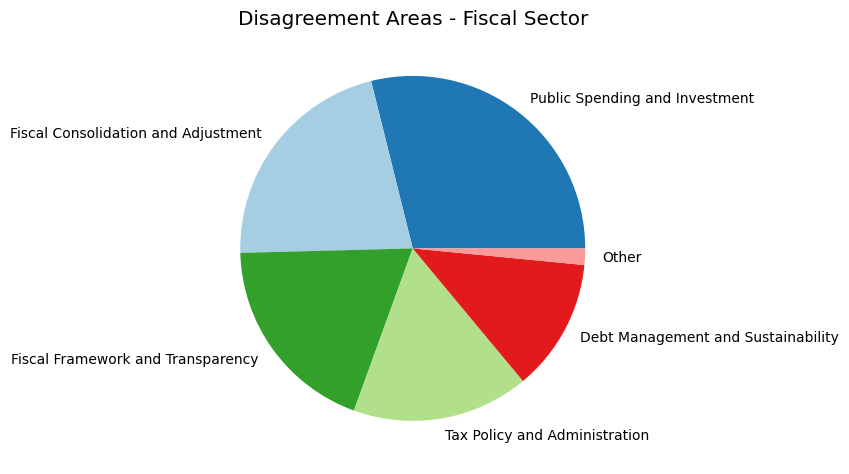

In [29]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Fiscal_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].apply(lambda x: x if x in ['fiscal consolidation pace', 'debt sustainability',
#        'pace of fiscal consolidation', 'tax policy',
#        'fiscal deficit projections', 'fiscal deficit target',
#        'pace of fiscal adjustment', 'fiscal sustainability',
#        'fiscal policy stance', 'tax exemptions'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Fiscal_gpt'].apply(lambda x: list(x.keys()) if x != 0 else []))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)

plt.ylabel('')
plt.title('Disagreement Areas - Fiscal Sector')

In [30]:
# list(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['External_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index)

field_dict = {
  "Exchange Rate Policies": [
    "exchange rate policy",
    "exchange rate flexibility",
    "exchange rate overvaluation",
    "exchange rate assessment",
    "exchange rate valuation",
    "exchange rate adjustment",
    "real exchange rate valuation",
    "exchange rate unification",
    "REER misalignment",
    "REER undervaluation",
    "exchange restrictions",
    "REER assessment methodology",
    "exchange rate regime",
    "real exchange rate overvaluation",
    "exchange rate measures",
    "exchange rate misalignment",
    "exchange rate controls",
    "REER assessment",
    "exchange rate depreciation",
    "REER undervaluation interpretation",
    "exchange rate stability",
    "exchange rate adjustment necessity",
    "exchange rate directives",
    "exchange rate adjustment pace",
    "FX restrictions",
    "FX market interventions",
    "FX macroprudential measures",
    "FX market efficiency",
    "FX market measures",
    "foreign exchange market", "equilibrium REER level",
  ],
  "Current Account Assessments": [
    "current account deficit",
    "current account assessment",
    "current account surplus",
    "external balance assessment",
    "current account surplus interpretation",
    "current account surplus causes",
    "current account deficit projections",
    "current account sustainability",
    "current account norm",
    "current account deficit assessment",
    "current account and reserves outlook",
    "current account deficit norm",
    "current account outlook",
    "current account gap assessment",
    "current account deficit management",
    "current account imbalances",
    "current account deficit projection",
    "current account deficit interpretation",
    "current account surplus assessment",
    "current account surplus explanation",
    "current account balance outlook",
    "current account deficit outlook",
    "current account deficit causes",
    "current account deficit concerns",
    "current account norm estimation"
  ],
  "External Stability": [
    "external position assessment",
    "external imbalances",
    "External stability assessment",
    "external balance assessment methodology",
    "external assessment methodology",
    "external sector assessment framework"
  ],
  "External Financing": [
    "external sector assessment",
    "external financing needs",
    "external financing challenges",
    "external borrowing justification"
  ],
  "Trade Policies": [
    "trade policies",
    "trade policy and tariffs",
    "temporary export restrictions and price controls",
    "trade restrictions",
    "trade policy",
    "trade policy direction",
    "trade barriers",
    "trade and investment restrictiveness",
    "trade tensions"
  ],
  "Reserves Management": [
    "reserve adequacy",
    "reserve adequacy assessment",
    "gold reserves management",
    "reserve accumulation",
    "international reserves measurement",
    "foreign reserve adequacy",
    "pace of reserve accumulation",
    "foreign exchange reserves adequacy",
    "special reserve ratio"
  ],
  "Competitiveness": [
    "competitiveness assessment",
    "competitiveness concerns",
    "competitiveness indicators",
    "competitiveness gap",
    "ULCs and export competitiveness"
  ],
  "External Debt Management": [
    "EBA assessment",
    "debt sustainability",
    "external debt management",
    "risk of debt distress"
  ],
  "Financial Flows and Interventions": [
    "External balance assessment",
    "foreign exchange intervention data transparency",
    "foreign exchange intervention transparency",
    "import restrictions",
    "grant financing",
    "Capital Flow Management measures",
    "CBI inflows impact"
  ],
  "Other": [
    "growth trajectory",
    "growth expectations",
    "current account deficit sustainability",
    "exchange rate role in external imbalances",
    "exports projections",
    "energy price persistence",
    "EBA model reservations",
    "growth and inflation projections",
    "analytical approaches and models",
    "remittances impact",
    "Northern Ireland Protocol",
    "airport tax impact on tourism",
    "downside risks",
    "export volatility",
    "dairy price volatility",
    "tax on wire transfers",
    "correspondent banking relationships",
    "BOP outlook",
    "CA gap and REER overvaluation",
    "REER gap explanation",
    "import barriers",
    "reform implementation gaps",
    "oil price assumptions",
    "repatriation mechanism",
    "customs inspections",
    "external sector assessment",
    "external sector assessment methodology"
  ]
}

Text(0.5, 1.0, 'Disagreement Areas - External Sector')

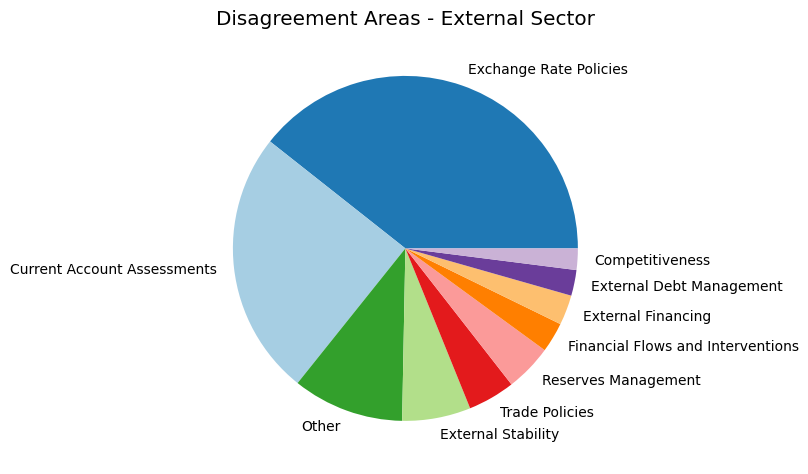

In [31]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['External_gpt'].apply(lambda x: list(x.keys())))))[0].apply(lambda x: x if x in ['exchange rate policy', 'exchange rate flexibility',
#        'current account deficit', 'external position assessment',
#        'current account assessment', 'exchange rate overvaluation',
#        'external balance assessment', 'current account surplus',
#        'exchange rate assessment', 'exchange rate valuation'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['External_gpt'].apply(lambda x: list(x.keys()) if x != 0 else []))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)

plt.ylabel('')
plt.title('Disagreement Areas - External Sector')

In [32]:
# list(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Financial_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index)

field_dict = {
  "Macroprudential Policy": [
    "macroprudential measures",
    "macroprudential policy stance",
    "borrower-based measures",
    "pace of macro-prudential tightening",
    "macroprudential authority",
    "macroprudential limits on primary residences",
    "macroprudential tools",
    "expansion of macroprudential tools",
    "implementation of macroprudential measures",
    "activation of CCyB",
    "macroprudential policy tools",
    "macroprudential policy mandate",
    "macroprudential policy framework",
    "macroprudential intervention necessity",
    "macroprudential measures classification",
    "macroprudential policy effectiveness",
    "macroprudential tools activation",
    "macroprudential toolkit expansion",
    "additional borrower-based tools",
    "housing-related capital flow management measures",
    "focus on countercyclical buffer vs risk weights"
  ],
  "Banking Sector Dynamics": [
    "banking sector vulnerabilities",
    "banking sector resilience",
    "banking sector stability",
    "importance of non-bank sector",
    "banking sector challenges",
    "financial stability framework",
    "banking sector stress testing",
    "banking sector restructuring",
    "banking sector regulation",
    "banking sector issues",
    "banking sector provisioning",
    "banking sector reform timeline",
    "banking system efficiency",
    "banking system challenges",
    "bank liquidity and solvency risks",
    "financial sector challenges post-DDEP",
    "banking supervision",
    "bank supervision and divestment",
    "banking law enactment",
    "bank profitability",
    "bank resolution framework",
    "banking system restructuring",
    "financial sector vulnerabilities",
    "systemic financial sector risks"
  ],
  "Non-Performing Loans": [
    "NPL management",
    "NPL reduction strategy",
    "non-performing loans",
    "NPL resolution strategy",
    "NPL recovery rate estimation",
    "NPLs resolution",
    "NPL resolution pace",
    "NPL reduction pace",
    "nonperforming loans",
    "NPL expectations",
    "NPL resolution speed",
    "NPL strategy",
    "pace of NPL resolution",
    "pace of NPL reduction",
    "credit bureau and foreclosure legislation",
    "problem loan recognition",
    "need for third-party asset quality review",
    "foreclosure framework",
    "loan classification standards",
    "comprehensive AQRs",
    "corporate debt-at-risk assessment",
    "credit risk assessment"
  ],
  "Regulation": [
    "regulatory and supervisory framework",
    "RBI supervisory powers over PSBs",
    "financial supervision reform",
    "PFSA governance structure",
    "regulatory independence",
    "regulatory measures",
    "supervision of non-bank financial sector",
    "provisioning requirements",
    "bank supervision and regulation",
    "PFI governance and role",
    "prudential requirements",
    "regulatory framework",
    "microfinance regulation",
    "bank governance reform",
    "crisis management framework",
    "supervisory perimeter",
    "governance of supervisory bodies",
    "institutional governance arrangements",
    "regulators' board composition and governance arrangements",
    "supervision of HBOR",
    "supervision of country and transfer risks",
    "supervision of financial cooperatives",
    "supervisory resources",
    "FSAP recommendations",
    "financial oversight architecture",
    "financial sector oversight",
    "PFI governance strategy",
    "CRSM governance and control",
    "regulatory gaps between NBFIs and banks",
    "holdings regulation and supervision",
    "timeliness of self-regulation",
    "BCP assessment",
    "reserve requirements",
    "AML/CFT framework",
    "AML/CFT framework implementation"
  ],
  "Financial Sector Reforms": [
    "bank restructuring strategy",
    "state-owned banks reform",
    "FGC transformation",
    "adoption of Basel III liquidity framework",
    "state support for banks",
    "bank restructuring and resolution framework",
    "Public financial institutions' activities",
    "public bank restructuring",
    "CRSM recapitalization strategy",
    "bank tax effects",
    "bank lending policies",
    "privatization of public banks",
    "SOB reform",
    "SOCBs recapitalization",
    "state ownership in financial sector",
    "state role in banking",
    "Air Seychelles restructuring",
    "HETA resolution strategy",
    "NPE resolution and bank governance",
    "timing of financial sector reforms",
    "bank undercapitalization resolution timing",
    "banking sector reform timeline",
    "resolution of AIB",
    "problem bank resolution",
    "bank recapitalization approach",
    "dedollarization strategy",
    "pace and sequence of CBS reorganization",
    "pace of deleveraging"
  ],
  "Housing Market": [
    "housing market risks",
    "housing market measures",
    "mortgage interest deductibility",
    "household debt risk",
    "real estate measures",
    "tax incentives on housing",
    "real estate market crisis",
    "real estate vulnerabilities",
    "housing price growth measures",
    "property sector stress",
    "housing market reforms",
    "Commercial real estate regulation",
    "housing-related tax changes",
    "housing tax preferences",
    "housing market vulnerabilities",
    "property market valuation",
    "property taxation",
    "provincial nonresident property transfer taxes",
    "residency-based LTV measure"
  ],
  "Credit and Liquidity": [
    "credit quotas and interest rate caps",
    "credit growth monitoring",
    "credit growth risk assessment",
    "credit growth",
    "rapid credit growth risk",
    "credit growth and regulation",
    "lending growth constraints",
    "credit growth risks",
    "credit growth measures",
    "credit growth policies",
    "credit to private sector",
    "credit allocation strategy",
    "credit gap assessment",
    "credit growth concerns",
    "credit standards for corporate loans",
    "lending policy",
    "liquidity management",
    "loan-to-value ratios",
    "debt-service-to-income caps",
    "DTI and DSTI limits",
    "LTV reduction pace",
    "borrower-based limits",
    "single borrower limits",
    "directed lending policy",
    "credit card indebtedness"
  ],
  "Interest Rate": [
    "interest rate ceilings",
    "interest rate ceiling",
    "interest rate caps",
    "usury rate adjustment",
    "interest rate policy",
    "interest rate cap",
    "bank asset tax",
    "amortization requirement",
    "debt-land swap",
    "corporate deleveraging strategy",
    "capital support program",
    "corporate balance sheet cleanup",
    "prudential measures for corporate debt",
    "debt-service-to-income caps",
    "loan guarantee schemes",
    "solvency stress test",
    "dividend distribution policy"
  ],
  "Financial Crisis": [
    "single financial stability fund",
    "emergency liquidity assistance",
    "deposit recovery strategy",
    "crisis management framework",
    "emergency lending assistance criteria",
    "DGS interventions",
    "single FSF",
    "deposit insurance fund",
    "deposit insurance public backstop",
    "temporary fiscal backstop for resolution funding"
  ],
  "Market Risks": [
    "digital currency risks",
    "FX lending to unhedged borrowers",
    "FX liquidity buffers",
    "FX mortgage litigation",
    "foreign-currency mortgage conversion",
    "risk assessment of foreign currency lending",
    "risk weights on bank holdings",
    "risk-based assessment tools",
    "banks' preference for holding net foreign assets",
    "banks' reliance on foreign funding",
    "cross-boundary use of e-CNY",
    "investment fund risk assessment",
    "FinTech initiatives",
    "SOV and DEZRA risks",
    "prudential measures against sovereign risks",
    "specific legislation weakening financial sector",
    "quasi-fiscal activities",
    "implicit guarantees for SOEs",
    "SOE subsidies",
    "impact of pandemic on financial sector",
    "external diagnostics on high risk portfolio",
    "household debt management",
    "household indebtedness risks",
    "income-based borrower measures",
    "correspondent banking relationships",
    "absence of a credit bureau",
    "auditor firm rotation",
    "bail-in rules",
    "bank account registry",
    "burden sharing",
    "entry of new banks",
    "legislative delays",
    "timing of Financial Stability Report",
    "use of monetary policy for financial stability",
    "role of AID Bank",
    "role of NBK in financial support",
    "UTOS operations"
  ],
  "Other": [
    "financial intermediation",
    "financial intermediation costs",
    "financial oversight",
    "BdL's role in intermediating funds",
    "correspondent banking relationships",
    "audit firm rotation"
  ]
}

Text(0.5, 1.0, 'Disagreement Areas - Financial Sector')

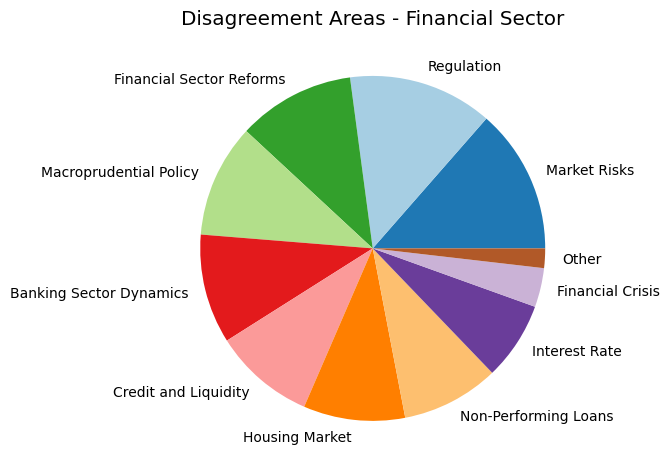

In [33]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Financial_gpt'].apply(lambda x: list(x.keys()) if type(x)!=int else []))))[0].apply(lambda x: x if x in ['macroprudential measures', 'housing market risks',
#        'bank restructuring strategy', 'NPL management',
#        'banking sector vulnerabilities', 'macroprudential policy stance',
#        'NPL reduction strategy', 'borrower-based measures',
#        'single financial stability fund',
#        'credit quotas and interest rate caps'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Financial_gpt'].apply(lambda x: list(x.keys()) if x != 0 else []))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)

plt.ylabel('')
plt.title('Disagreement Areas - Financial Sector')

In [34]:
# list(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Real_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index)

field_dict = {
  "Growth Outlook": [
    "growth projections",
    "growth outlook",
    "growth prospects",
    "economic growth projections",
    "economic growth outlook",
    "medium-term growth outlook",
    "GDP growth projections",
    "medium-term growth projections",
    "medium-term growth prospects",
    "growth forecast",
    "near-term growth prospects",
    "long-term growth projections",
    "GDP growth projection",
    "growth and inflation projections",
    "growth trajectory",
    "nonoil growth outlook",
    "economic growth forecast",
    "medium-term growth projection",
    "growth prospects for 2021",
    "pace of recovery",
    "short-term growth prospects",
    "investment growth projections",
    "growth dynamics",
    "medium-term potential growth rate",
    "growth projection",
    "growth potential",
    "oil and non-oil sector growth",
    "Economic growth projections",
    "GDP growth estimates",
    "growth potential from public investments"
  ],
  "Inflation": [
    "inflation projections",
    "inflation outlook",
    "inflation expectations",
    "core inflation persistence",
    "inflation persistence",
    "inflation dynamics",
    "Inflation projections"
  ],
  "Structural Reform": [
    "pace of structural reforms",
    "structural reforms",
    "minimum wage policy",
    "wage bargaining flexibility",
    "SOE reform",
    "labor market reform",
    "economic diversification",
    "preference provisions in public procurement",
    "structural reform implementation",
    "structural reform agenda",
    "pace of SOE reform",
    "policy support and vulnerabilities",
    "immigration policy",
    "privatization",
    "impact of structural reforms",
    "competitiveness strategy",
    "minimum wage framework",
    "pace of reform implementation",
    "structural competitiveness",
    "medium-term growth potential"
  ],
  "Labor Market": [
    "labor market reforms",
    "labor market flexibility",
    "unemployment",
    "labor market conditions",
    "employment estimates",
    "wage increases",
    "youth unemployment causes",
    "labor market duality",
    "wage flexibility",
    "youth unemployment",
    "wage negotiations",
    "labor tax wedge",
    "labor market regulations"
  ],
  "Economic Outlook": [
    "economic outlook",
    "economic recovery outlook",
    "economic outlook optimism",
    "economic momentum",
    "economic outlook representation",
    "economic slack assessment",
    "economic adaptation to appreciation",
    "economic scarring",
    "long-term scarring"
  ],
  "Sectoral Growth": [
    "productivity growth",
    "potential growth rate",
    "potential growth estimates",
    "output gap assessment",
    "productivity growth outlook",
    "non-mining sector recovery",
    "non-oil GDP recovery strength",
    "oil sector expansion",
    "non-oil growth outlook",
    "wage and productivity growth alignment",
    "wage and productivity dynamics",
    "work-based training effectiveness",
    "productivity impact of low-skilled labor absorption",
    "structural drivers of growth",
    "potential growth",
    "potential growth projections",
    "medium-term potential growth",
    "medium-term potential growth estimate",
    "potential growth estimation",
    "potential output estimate",
    "output losses from energy shock",
    "output gap estimation",
    "potential growth and output gap"
  ],
  "Market and Economic Conditions": [
    "impact of US-China trade tensions",
    "electricity tariff structure",
    "governance indicators",
    "product market liberalization",
    "poverty reduction strategy",
    "poverty measurement",
    "growth slowdown characterization",
    "wage growth and competitiveness",
    "wage growth vs productivity",
    "impact of political unrest",
    "house price inflation",
    "business environment",
    "electricity shortages",
    "housing market pressures",
    "real estate market correction",
    "rental market policies",
    "minimum wage impact",
    "impact of political uncertainty on investment"
  ],
  "External Factors": [
    "tourism recovery pace",
    "tourism prospects",
    "tourism recovery",
    "tourism recovery expectations",
    "pace of recovery in construction sector",
    "Honduras 2020 plan impact",
    "zero-COVID strategy impact",
    "medium-term growth path",
    "profile of recovery",
    "pandemic scars on human capital",
    "energy policy",
    "import substitution strategy",
    "presentation of social tensions",
    "role of the state",
    "land reform",
    "private business investment",
    "public investment focus",
    "ALMP and R&D spending cuts",
    "wage indexation",
    "wage indexation framework",
    "permanent effects of 2015-16 crisis on potential output",
    "wage growth projection",
    "overheating risk"
  ]
}

Text(0.5, 1.0, 'Disagreement Areas - Real Sector')

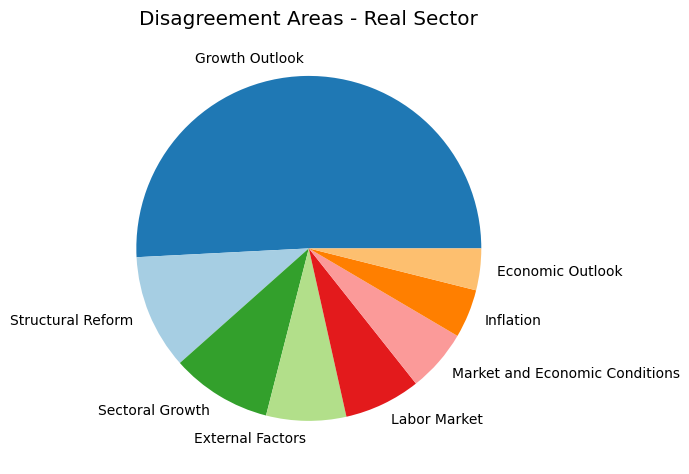

In [35]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Real_gpt'].apply(lambda x: list(x.keys()) if type(x)!=int else []))))[0].apply(lambda x: x if x in ['growth projections', 'growth outlook', 'growth prospects',
#        'labor market reforms', 'economic growth projections',
#        'economic growth outlook', 'inflation projections',
#        'pace of structural reforms', 'structural reforms', 'economic outlook'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['Real_gpt'].apply(lambda x: list(x.keys()) if x != 0 else []))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)

plt.ylabel('')
plt.title('Disagreement Areas - Real Sector')

In [40]:
# list(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['other_areas_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index)
docs = list(set(pd.DataFrame(list(itertools.chain.from_iterable(df_documents['other_areas_gpt'].apply(lambda x: list(x.keys()) if x!=0 else []))))[0].value_counts().index))

from bertopic import BERTopic

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

field_dict = {}
topic_name_l = ['Other', 'Labor Market', 'Climate Change and Environment', 'Governance and Anti-Corruption', 'Diversification', 'Structural Reforms', 'Energy Sector', 'Immigration and Trade', 'Housing Market',
 'Infrastructure Investment', 'Fiscal Reforms', 'SOE Reforms', 'Inequality', 'Political Stability', 'Debt Sustainability']
topic_dict = topic_model.get_document_info(docs).set_index(['Document'])['Topic'].to_dict()
for i in range(-1,14):
    field_dict[topic_name_l[i+1]] = [t for t in topic_dict if topic_dict[t]==i]

/data/home/xiong/miniconda3/envs/traction/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [44]:
# pd.DataFrame(list(itertools.chain.from_iterable(df_documents['other_areas_gpt'].apply(lambda x: list(x.keys()) if type(x)!=int else []))))[0].apply(lambda x: x if x in ['structural reforms', 'Climate Change', 'governance and corruption',
#        'Structural Reforms', 'Governance and Corruption',
#        'governance and transparency', 'climate change adaptation',
#        'AML/CFT framework', 'climate change policies',
#        'climate change strategy'] else 'other').value_counts().plot.pie()

df_temp = pd.DataFrame(list(itertools.chain.from_iterable(df_documents['other_areas_gpt'].apply(lambda x: list(x.keys()) if x != 0 else []))))
df_temp[0].apply(lambda x: [var for var in field_dict if x in field_dict[var]][0]).value_counts().plot.pie(colors=colors_cate)

plt.ylabel('')
plt.title('Other Disagreement Areas')

IndexError: list index out of range

monetary policy

In [45]:
sector = 'mon'

df_documents[sector+'_disagreement_areas_gpt_ft'] = df_documents[sector+'_disagreement_areas_gpt_ft'].apply(lambda x: ast.literal_eval(x) if x==x and '[' in x else x if x==x else x)
# df_documents[sector+'_disagreement_areas_gpt_ft'] = df_documents[sector+'_disagreement_areas_gpt_ft'].apply(lambda x: x[0] if x==x else x)
df_documents[sector+'_disagreement_areas_gpt_ft'] = df_documents[sector+'_disagreement_areas_gpt_ft'].apply(lambda x: [x] if type(x)==str else x)

df_sector = df_documents[(df_documents['monetary_sample'])&(~df_documents[sector+'_'+'agreement_gpt_ft'].isna())]
df_sector['stance_future_gpt_ft_staff'] = df_sector[sector+'_'+'stance_future_gpt_ft_staff'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['stance_future_gpt_ft_buff'] = df_sector[sector+'_'+'stance_future_gpt_ft_buff'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['stance_current_gpt_ft_buff'] = df_sector[sector+'_'+'stance_current_gpt_ft_buff'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['stance_current_gpt_ft_staff'] = df_sector[sector+'_'+'stance_current_gpt_ft_staff'].fillna('irrelevant')
df_sector['agreement_gpt_ft'] = df_sector[sector+'_'+'agreement_gpt_ft'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['disagreement_areas_gpt_ft'] = df_sector[sector+'_'+'disagreement_areas_gpt_ft'].apply(lambda x: x if x==x else [])

df_sector['stance_current_gpt_ft_staff'] = df_sector['stance_current_gpt_ft_staff'].apply(lambda x: 'restrictive' if x in ['moderately tight', 'tightening bias'] else 'neutral' if x in ['close to neutral'] else x)
df_sector['stance_current_gpt_ft_buff'] = df_sector['stance_current_gpt_ft_buff'].apply(lambda x: 'restrictive' if x in ['moderately tight', 'tightening bias'] else 'neutral' if x in ['close to neutral'] else x)


In [46]:
df_sector['year'] = df_sector['year'].apply(lambda x: int(x))

In [47]:
stance_dict = {'tightening': 5, 'tightening bias': 4, 'no change': 3, 'loosening bias': 2, 'loosening': 1}
df_sector['stance_future_gpt_ft_staff_num'] = df_sector['stance_future_gpt_ft_staff'].apply(lambda x: stance_dict[x] if x in stance_dict else np.nan)
df_sector['stance_future_gpt_ft_buff_num'] = df_sector['stance_future_gpt_ft_buff'].apply(lambda x: stance_dict[x] if x in stance_dict else np.nan)
df_sector['agreement_stance_future_gpt_ft_num'] = df_sector['stance_future_gpt_ft_staff_num']-df_sector['stance_future_gpt_ft_buff_num']
df_sector['agreement_stance_future_gpt_ft_cate1'] = df_sector['agreement_stance_future_gpt_ft_num'].apply(lambda x: 'major difference' if x >= 3 or x <= -3 else 'some difference' if x in [2, -2] else 'minor difference' if x in [1, -1] else 'no difference' if x==0 else 'irrelevant')
df_sector['agreement_stance_future_gpt_ft_cate2'] = df_sector['agreement_stance_future_gpt_ft_num'].apply(lambda x: 'significantly tighter' if x >= 3 else 'tighter' if x==2 else 'moderately tighter' if x==1 else 'same' if x==0 else 'moderately looser' if x==-1 else 'looser' if x==-2 else 'significantly looser' if x<=-3 else 'irrelevant')

stance_current_dict = {'accommodative': 0, 'neutral': 1, 'restrictive': 2}
df_sector['stance_current_gpt_ft_staff_num'] = df_sector['stance_current_gpt_ft_staff'].apply(lambda x: stance_current_dict[x] if x in stance_current_dict else np.nan)
df_sector['stance_current_gpt_ft_buff_num'] = df_sector['stance_current_gpt_ft_buff'].apply(lambda x: stance_current_dict[x] if x in stance_current_dict else np.nan)
df_sector['agreement_stance_current_gpt_ft_num'] = df_sector['stance_current_gpt_ft_staff_num']-df_sector['stance_current_gpt_ft_buff_num']
df_sector['agreement_stance_current_gpt_ft_cate2'] = df_sector['agreement_stance_current_gpt_ft_num'].apply(lambda x: 'same' if x==0 else 'more accommodative' if x<0 else 'more restrictive' if x>0 else 'irrelevant')

df_sector['agreement_stance_current_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['stance_current_gpt_ft_staff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_current_gpt_ft_staff']!=x['stance_current_gpt_ft_staff'] or x['stance_current_gpt_ft_buff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_current_gpt_ft_buff']!=x['stance_current_gpt_ft_buff'] else 'mostly agree' if x['stance_current_gpt_ft_staff']==x['stance_current_gpt_ft_buff'] else 'disagreement exists', axis=1)
# df_sector['agreement_stance_future_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['stance_future_gpt_ft_staff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_future_gpt_ft_staff']!=x['stance_future_gpt_ft_staff'] or x['stance_future_gpt_ft_buff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_future_gpt_ft_buff']!=x['stance_future_gpt_ft_buff'] else 'mostly agree' if x['stance_future_gpt_ft_staff']==x['stance_future_gpt_ft_buff'] else 'disagreement exists', axis=1)
df_sector['agreement_stance_future_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['stance_future_gpt_ft_staff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_future_gpt_ft_staff']!=x['stance_future_gpt_ft_staff'] or x['stance_future_gpt_ft_buff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_future_gpt_ft_buff']!=x['stance_future_gpt_ft_buff'] else 'mostly agree' if x['agreement_stance_future_gpt_ft_num'] in [-1, 0, 1] else 'disagreement exists', axis=1)


In [48]:
# df_sector['agreement_general_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['agreement_stance_current_gpt_ft']=='irrelevant' and x['agreement_stance_future_gpt_ft']=='irrelevant' and x['agreement_gpt_ft']=='irrelevant' else 'disagreement exists' if x['agreement_stance_current_gpt_ft']=='disagreement exists' or x['agreement_stance_future_gpt_ft']=='disagreement exists' or x['agreement_gpt_ft']=='disagreement exists' else 'mostly agree', axis=1)
df_sector['agreement_general_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['agreement_stance_current_gpt_ft']=='irrelevant' and x['agreement_stance_future_gpt_ft']=='irrelevant' and x['agreement_gpt_ft']=='irrelevant' else 'disagreement exists' if x['agreement_stance_current_gpt_ft']=='disagreement exists' or x['agreement_stance_future_gpt_ft_num']>1 or x['agreement_stance_future_gpt_ft_num']<-1 or (x['agreement_gpt_ft']=='disagreement exists' and x['disagreement_areas_gpt_ft']!='Future Policy Direction') else 'mostly agree', axis=1)

# df_sector['disagreement_areas_general_gpt_ft'] = df_sector['disagreement_areas_gpt_ft'].fillna('').apply(lambda x: '' if x==[] else x)
df_sector['disagreement_areas_general_gpt_ft'] = df_sector.apply(lambda x: (x['disagreement_areas_gpt_ft']+['current policy stance']) if x['agreement_stance_current_gpt_ft']=='disagreement exists' and 'current policy stance' not in x['disagreement_areas_gpt_ft'] else x['disagreement_areas_gpt_ft'], axis=1)
df_sector['disagreement_areas_general_gpt_ft'] = df_sector.apply(lambda x: (x['disagreement_areas_general_gpt_ft']+['future policy direction']) if x['agreement_stance_future_gpt_ft']=='disagreement exists' and 'future policy direction' not in x['disagreement_areas_gpt_ft'] else x['disagreement_areas_gpt_ft'], axis=1)
df_sector['disagreement_areas_general_gpt_ft'] = df_sector.apply(lambda x: [m for m in x['disagreement_areas_general_gpt_ft'] if m!='future policy direction'] if 'future policy direction' in x['disagreement_areas_general_gpt_ft'] and x['agreement_stance_future_gpt_ft']!='disagreement exists' else x['disagreement_areas_general_gpt_ft'], axis=1)

In [49]:
key_columns = ['stance_current_gpt_ft_staff', 'stance_future_gpt_ft_staff',
       'stance_current_gpt_ft_buff', 'stance_future_gpt_ft_buff',
       'agreement_general_gpt_ft', 'disagreement_general_areas_gpt_ft']

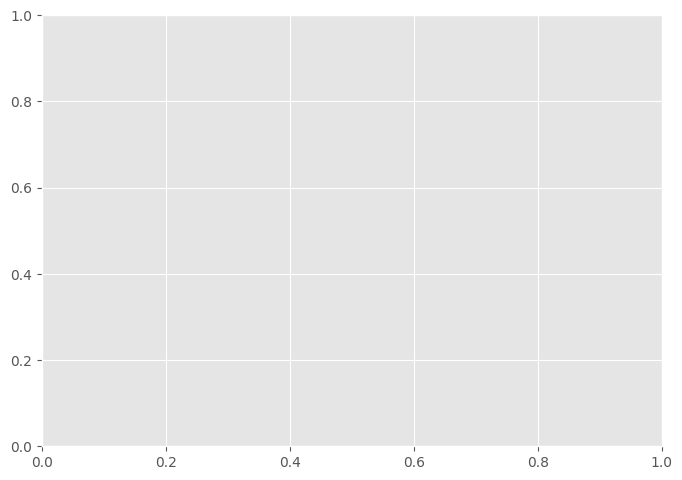

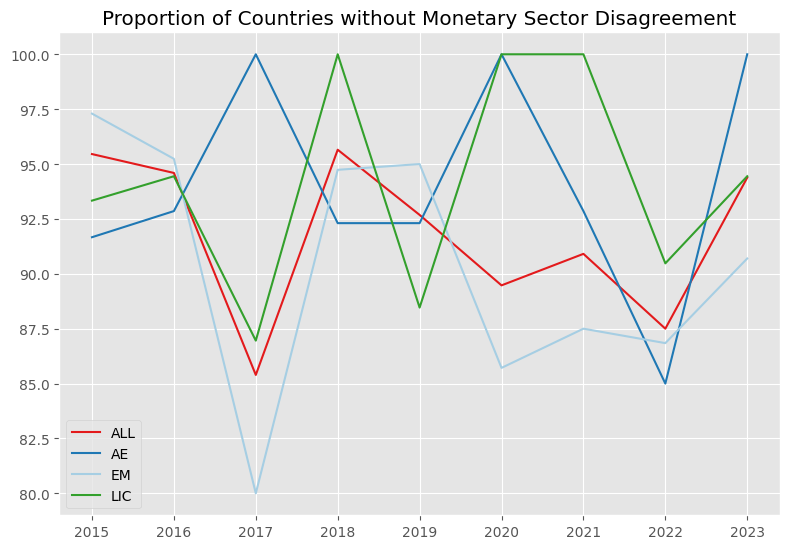

In [50]:
fig, ax = plt.subplots()

df_temp = (100-(df_sector.set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100).rename(columns={'agreement_general_gpt_ft': 'ALL'})
for c in ['AE', 'EMDE', 'LIC']:
    df_temp = df_temp.merge(100-(df_sector[df_sector['Classification']==c+'s'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100, left_index=True, right_index=True, how='outer').rename(columns={'agreement_general_gpt_ft': c})
ax = df_temp.plot(color=[colors_cate[4]]+colors_cate)

# y = (100-(df_sector[df_sector['Classification']=='LICs'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()['agreement_general_gpt_ft']*100).values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Proportion of Countries without Monetary Sector Disagreement')
plt.ylabel('')
plt.xlabel('')
plt.legend(['ALL', 'AE', 'EM', 'LIC'])
plt.tight_layout()
# plt.ylim(-5, 100)

# fig, ax = plt.subplots()

# df_temp = ((df_sector.set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100).rename(columns={'agreement_general_gpt_ft': 'ALL'})
# for c in ['AE', 'EMDE', 'LIC']:
#     df_temp = df_temp.merge((df_sector[df_sector['Classification']==c+'s'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100, left_index=True, right_index=True, how='outer').rename(columns={'agreement_general_gpt_ft': c})
# ax = df_temp.plot(color=[colors_cate[4]]+colors_cate)

# y = ((df_sector[df_sector['Classification']=='LICs'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()['agreement_general_gpt_ft']*100).values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

# plt.title('Proportion of Countries without Monetary Sector Disagreement by Year-Income Group')
# plt.ylabel('')
# plt.xlabel('')
# plt.legend(['ALL', 'AE', 'EM', 'LIC'])
# # plt.ylim(-5, 100)

<IPython.core.display.Javascript object>


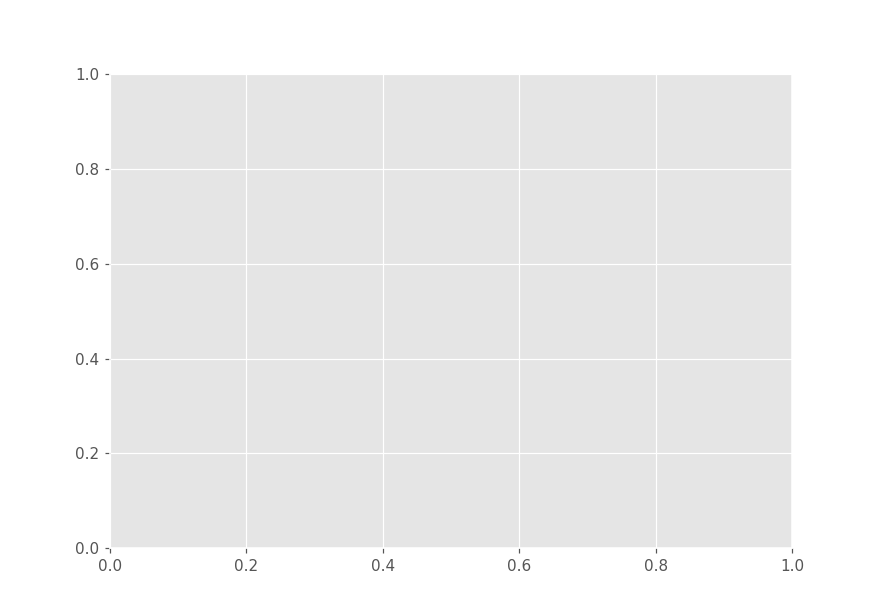

<IPython.core.display.Javascript object>


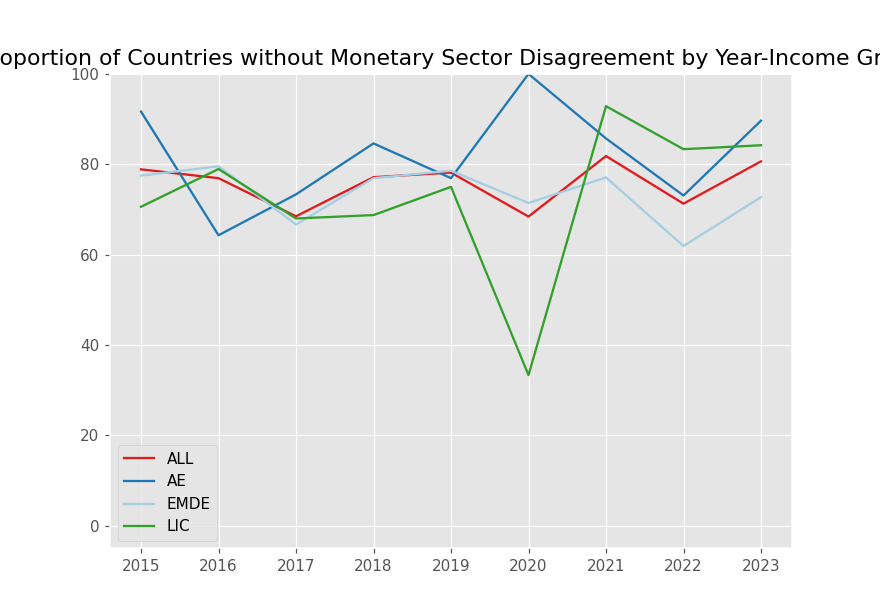

(-5.0, 100.0)

In [66]:
fig, ax = plt.subplots()

df_temp = ((df_sector.set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()*100).rename(columns={'agreement_general_gpt_ft': 'ALL'})
for c in ['AE', 'EMDE', 'LIC']:
    df_temp = df_temp.merge((df_sector[df_sector['Classification']==c+'s'].set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()*100, left_index=True, right_index=True, how='outer').rename(columns={'agreement_general_gpt_ft': c})
ax = df_temp.plot(color=[colors_cate[4]]+colors_cate)

# y = ((df_sector[df_sector['Classification']=='LICs'].set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()['agreement_general_gpt_ft']*100).values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Proportion of Countries without Monetary Sector Disagreement by Year-Income Group')
plt.ylabel('')
plt.xlabel('')
plt.ylim(-5, 100)

In [51]:
area_dict = {'Welfare Case': 'Inflation Target', 'Projects for future wage growth': 'Economic Assessment', 'Convention on Institutional Framework': 'Institutions', 'Sacrifice Ratio': 'Economic Assessment'}
to_drop_l = ['Fiscal Policy', 'Investment Efficiency', 'Policy Assessment']
df_sector['disagreement_areas_general_gpt_ft_revised'] = df_sector['disagreement_areas_general_gpt_ft']
# for area in area_dict:
#     df_sector['disagreement_areas_general_gpt_ft_revised'] = df_sector['disagreement_areas_general_gpt_ft_revised'].apply(lambda x: x.replace(area, area_dict[area]))
# for area in to_drop_l:
#     df_sector['disagreement_areas_general_gpt_ft_revised'] = df_sector['disagreement_areas_general_gpt_ft_revised'].apply(lambda x: x.replace(area, '').strip('; '))

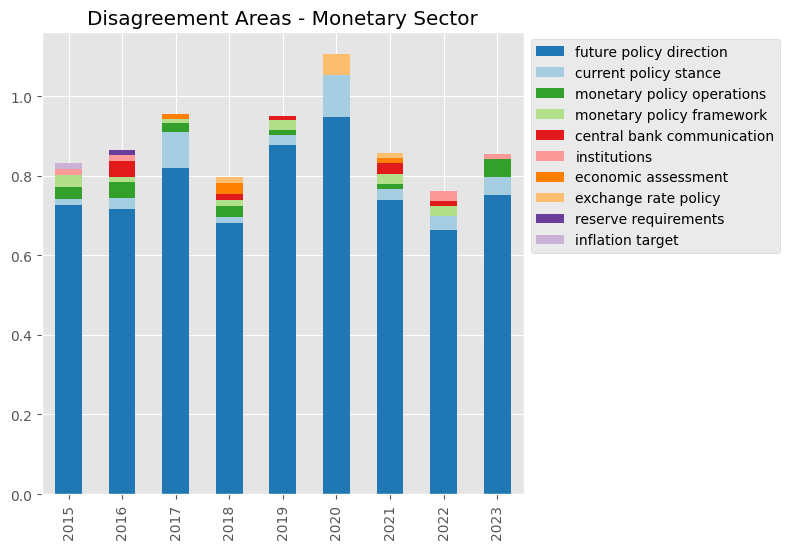

In [52]:
df_temp = pd.DataFrame(itertools.chain.from_iterable(df_sector['disagreement_areas_general_gpt_ft_revised']))
index_l = df_temp[0].value_counts().index
df_temp['year'] = list(itertools.chain.from_iterable(df_sector.apply(lambda x: [x['year']]*len(x['disagreement_areas_general_gpt_ft_revised']) if x['disagreement_areas_general_gpt_ft_revised']!=[] else [], axis=1)))
df_temp = df_temp.groupby('year')[0].value_counts().reset_index().rename(columns={0:'areas'})
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['areas'], values='count').fillna(0)
pivot = (pivot.T/df_sector.groupby('year').count()['country']).T # pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[index_l]
ax = pivot.plot.bar(stacked=True, color=colors_cate)
ax.set_title('Disagreement Areas - Monetary Sector')
plt.legend(index_l, loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

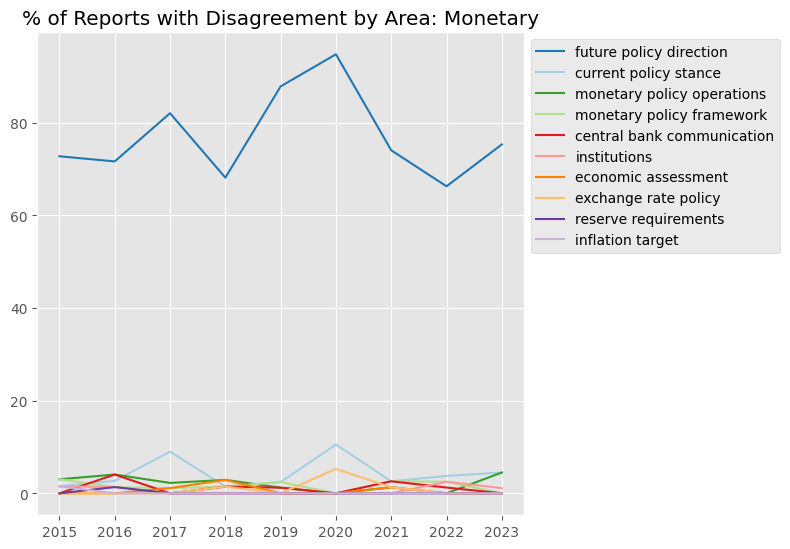

In [53]:
ax = (pivot*100).plot(color=colors_cate)
ax.set_title('% of Reports with Disagreement by Area: Monetary')
plt.legend(index_l, loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
# plt.ylim(-5, 100)
plt.tight_layout()

Text(0.5, 0, '')

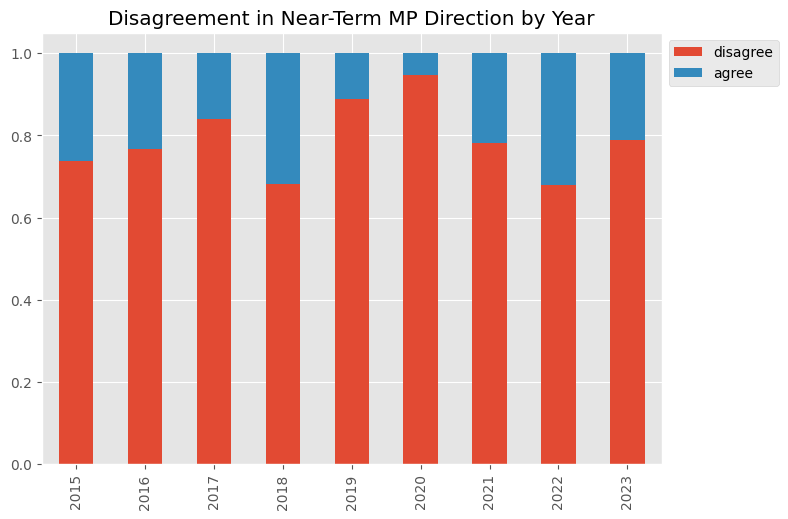

In [54]:
df_temp = df_sector[df_sector['agreement_stance_future_gpt_ft']!='irrelevant'].groupby('year')['agreement_stance_future_gpt_ft'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['agreement_stance_future_gpt_ft'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
# pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'irrelevant', 'loosening bias', 'loosening']]
pivot = pivot[['disagreement exists', 'mostly agree']]
ax = pivot.plot.bar(stacked=True)
ax.set_title('Disagreement in Near-Term MP Direction by Year')
plt.legend(['disagree', 'agree'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')

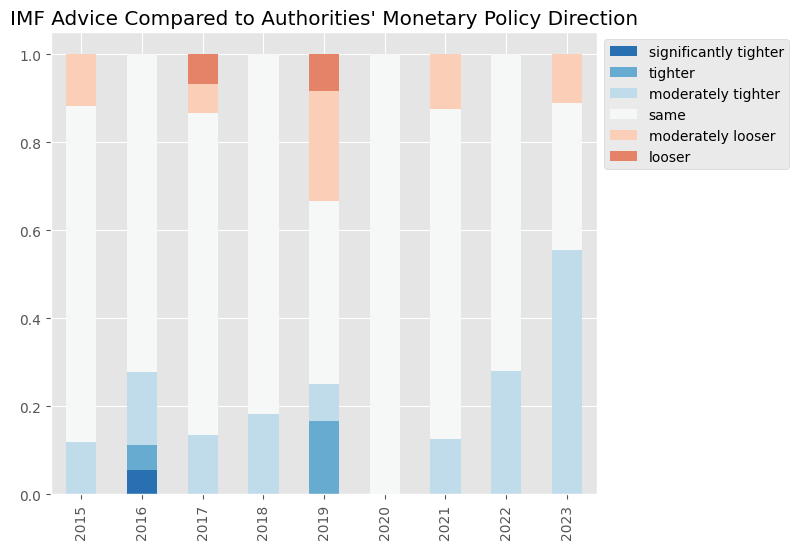

In [55]:
df_temp = df_sector[df_sector['agreement_stance_future_gpt_ft_cate2']!='irrelevant'].groupby('year')['agreement_stance_future_gpt_ft_cate2'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['agreement_stance_future_gpt_ft_cate2'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
# pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'irrelevant', 'loosening bias', 'loosening']]
pivot = pivot[['significantly tighter', 'tighter', 'moderately tighter', 'same', 'moderately looser', 'looser']]
ax = pivot.plot.bar(stacked=True, color=colors7)
ax.set_title('IMF Advice Compared to Authorities\' Monetary Policy Direction')
plt.legend(['significantly tighter', 'tighter', 'moderately tighter', 'same', 'moderately looser', 'looser', 'significantly looser'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

Text(0.5, 0, '')

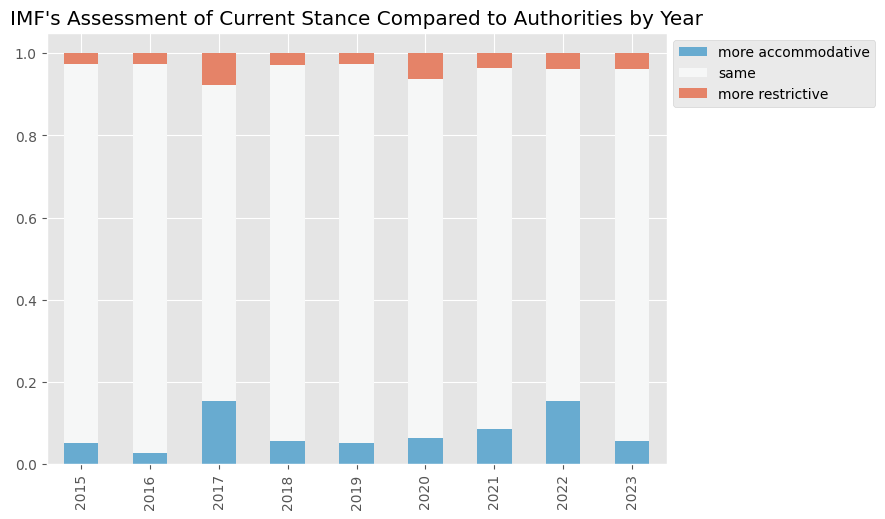

In [57]:
df_temp = df_sector[df_sector['agreement_stance_current_gpt_ft_cate2']!='irrelevant'].groupby('year')['agreement_stance_current_gpt_ft_cate2'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['agreement_stance_current_gpt_ft_cate2'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['more accommodative', 'same', 'more restrictive']]
ax = pivot.plot.bar(stacked=True, color=colors3)
ax.set_title('IMF\'s Assessment of Current Stance Compared to Authorities by Year')
plt.legend(['more accommodative', 'same', 'more restrictive'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')

In [58]:
df_sector[df_sector['stance_future_gpt_ft_buff'].apply(lambda x: x not in ['irrelevant'])].groupby('year')['stance_future_gpt_ft_buff']

In [59]:
df_temp = df_sector[df_sector['stance_future_gpt_ft_buff'].apply(lambda x: x not in ['irrelevant'])].groupby('year')['stance_future_gpt_ft_buff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['stance_future_gpt_ft_buff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors6)
# ax.set_title('Staff\'s Policy Advice by Year')
ax.set_title('Authorities\' Monetary Policy Direction by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()
plt.rcParams['figure.figsize'] = (8,4)

KeyError: "['no change', 'unclear'] not in index"

In [60]:
df_temp = df_sector[df_sector['stance_future_gpt_ft_staff'].apply(lambda x: x not in ['irrelevant'])].groupby('year')['stance_future_gpt_ft_staff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['stance_future_gpt_ft_staff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors6)
ax.set_title('Staff\'s Monetary Policy Advice by Year')
# ax.set_title('Authorities\' Policy Direction by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

KeyError: "['no change', 'unclear'] not in index"

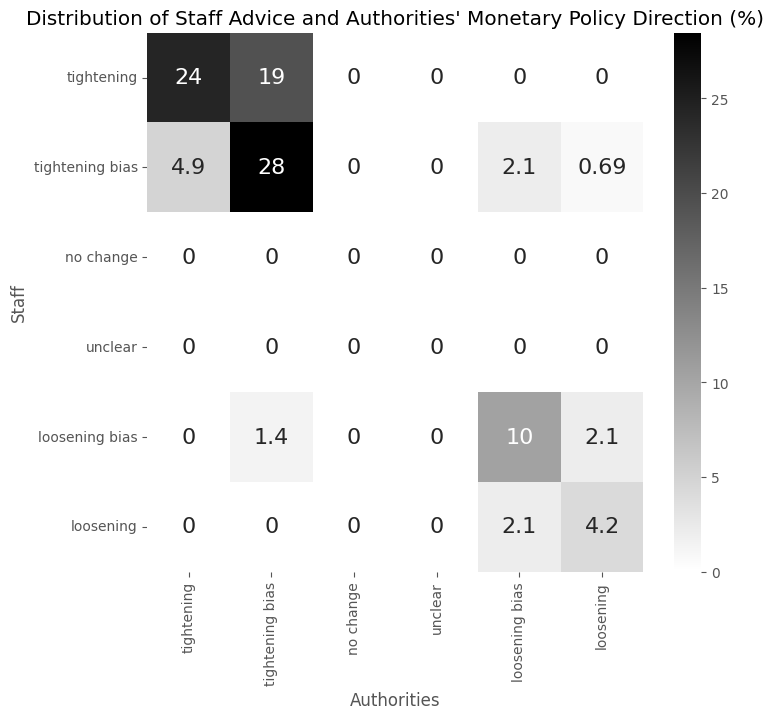

<Figure size 800x700 with 0 Axes>

In [61]:
plt.rcParams['figure.figsize'] = (8,7)
labels = ['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']
cm = confusion_matrix(df_sector['stance_future_gpt_ft_staff'], df_sector['stance_future_gpt_ft_buff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.yticks(rotation='horizontal')
plt.xlabel('Authorities')
plt.ylabel('Staff')
plt.title('Distribution of Staff Advice and Authorities\' Monetary Policy Direction (%)')
plt.show()
plt.tight_layout()

fiscal

In [62]:
sector = 'fis'
df_documents[sector+'_disagreement_areas_gpt_ft'] = df_documents[sector+'_disagreement_areas_gpt_ft'].apply(lambda x: ast.literal_eval(x) if x==x and '[' in x else [x] if x==x else x)
df_sector = df_documents[(~df_documents[sector+'_'+'agreement_gpt_ft'].isna())]
df_sector['stance_near_term_gpt_ft_staff'] = df_sector[sector+'_'+'stance_near_term_gpt_ft_staff'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['stance_near_term_gpt_ft_buff'] = df_sector[sector+'_'+'stance_near_term_gpt_ft_buff'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['agreement_gpt_ft'] = df_sector[sector+'_'+'agreement_gpt_ft'].apply(lambda x: 'irrelevant' if x=='nan' else x)
df_sector['disagreement_areas_gpt_ft'] = df_sector[sector+'_'+'disagreement_areas_gpt_ft'].apply(lambda x: x if x==x else [])

In [63]:
stance_dict = {'tightening': 5, 'tightening bias': 4, 'no change': 3, 'loosening bias': 2, 'loosening': 1}
df_sector['stance_near_term_gpt_ft_staff_num'] = df_sector['stance_near_term_gpt_ft_staff'].apply(lambda x: stance_dict[x] if x in stance_dict else np.nan)
df_sector['stance_near_term_gpt_ft_buff_num'] = df_sector['stance_near_term_gpt_ft_buff'].apply(lambda x: stance_dict[x] if x in stance_dict else np.nan)
df_sector['agreement_stance_near_term_gpt_ft_num'] = df_sector['stance_near_term_gpt_ft_staff_num']-df_sector['stance_near_term_gpt_ft_buff_num']
df_sector['agreement_stance_near_term_gpt_ft_cate1'] = df_sector['agreement_stance_near_term_gpt_ft_num'].apply(lambda x: 'major difference' if x >= 3 or x <= -3 else 'some difference' if x in [2, -2] else 'minor difference' if x in [1, -1] else 'no difference' if x==0 else 'irrelevant')
df_sector['agreement_stance_near_term_gpt_ft_cate2'] = df_sector['agreement_stance_near_term_gpt_ft_num'].apply(lambda x: 'significantly tighter' if x >= 3 else 'tighter' if x==2 else 'moderately tighter' if x==1 else 'same' if x==0 else 'moderately looser' if x==-1 else 'looser' if x==-2 else 'significantly looser' if x<=-3 else 'irrelevant')

# df_sector['agreement_stance_near_term_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['stance_near_term_gpt_ft_staff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_near_term_gpt_ft_staff']!=x['stance_near_term_gpt_ft_staff'] or x['stance_near_term_gpt_ft_buff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_near_term_gpt_ft_buff']!=x['stance_near_term_gpt_ft_buff'] else 'mostly agree' if x['stance_near_term_gpt_ft_staff']==x['stance_near_term_gpt_ft_buff'] else 'disagreement exists', axis=1)
df_sector['agreement_stance_near_term_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['stance_near_term_gpt_ft_staff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_near_term_gpt_ft_staff']!=x['stance_near_term_gpt_ft_staff'] or x['stance_near_term_gpt_ft_buff'] in ['', 'nan', 'n','unclear', 'irrelevant'] or x['stance_near_term_gpt_ft_buff']!=x['stance_near_term_gpt_ft_buff'] else 'mostly agree' if x['agreement_stance_near_term_gpt_ft_num'] in [-1, 0, 1] else 'disagreement exists', axis=1)


In [64]:
# df_sector['agreement_general_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['agreement_stance_near_term_gpt_ft']=='irrelevant' and x['agreement_gpt_ft']=='irrelevant' else 'disagreement exists' if x['agreement_stance_near_term_gpt_ft']=='disagreement exists' or x['agreement_gpt_ft']=='disagreement exists' else 'mostly agree', axis=1)
df_sector['agreement_general_gpt_ft'] = df_sector.apply(lambda x: 'irrelevant' if x['agreement_stance_near_term_gpt_ft']=='irrelevant' and x['agreement_gpt_ft']=='irrelevant' else 'disagreement exists' if x['agreement_stance_near_term_gpt_ft_num'] not in [-1, 0, 1] or (x['agreement_gpt_ft']=='disagreement exists' and x['disagreement_areas_gpt_ft']!="['near-term policy direction']") else 'mostly agree', axis=1)

df_sector['disagreement_areas_general_gpt_ft'] = df_sector['disagreement_areas_gpt_ft']
df_sector['disagreement_areas_general_gpt_ft'] = df_sector.apply(lambda x: (x['disagreement_areas_general_gpt_ft']+['near-term policy direction']) if x['agreement_stance_near_term_gpt_ft']=='disagreement exists' and 'near-term policy direction' not in x['disagreement_areas_general_gpt_ft'] else x['disagreement_areas_general_gpt_ft'], axis=1)
df_sector['disagreement_areas_general_gpt_ft'] = df_sector.apply(lambda x: [m for m in x['disagreement_areas_general_gpt_ft'] if m != 'near-term policy direction'] if 'near-term policy direction' in x['disagreement_areas_general_gpt_ft'] and x['agreement_stance_near_term_gpt_ft']!='disagreement exists' else x['disagreement_areas_general_gpt_ft'], axis=1)

In [65]:
df_sector['year'] = df_sector['year'].apply(lambda x: int(x))

In [66]:
key_columns = ['stance_near_term_gpt_ft_staff', 'stance_near_term_gpt_ft_buff',
       'agreement_gpt_ft', 'disagreement_areas_gpt_ft']

In [67]:
df_sector['agreement_gpt_ft'] = df_sector['agreement_gpt_ft'].apply(lambda x: 'mostly agree' if x in ['Micah mostly agree', 'appropriately agree', 'валлийский'] else x)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 9 but size of corresponding boolean axis is 10

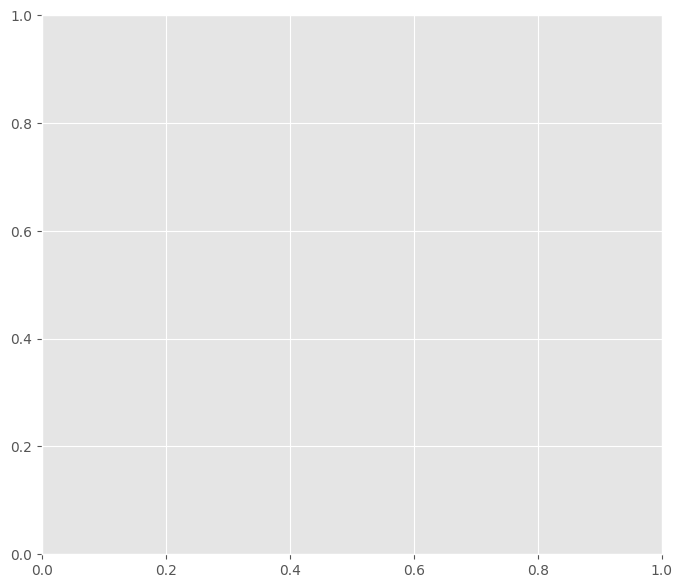

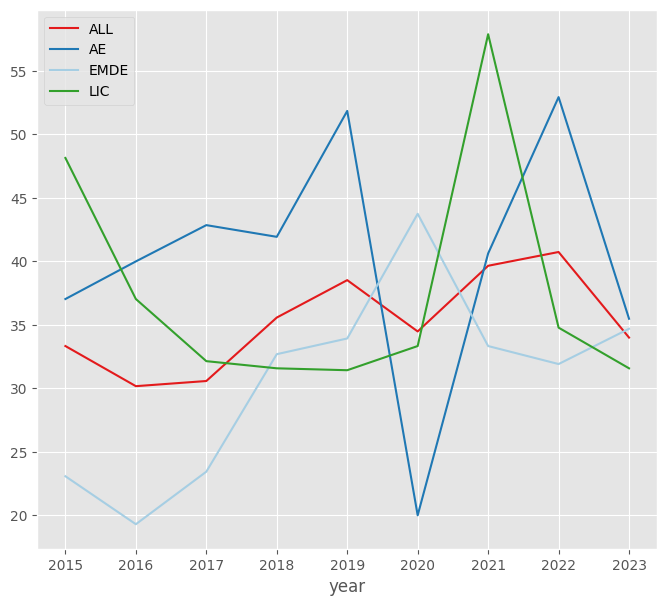

In [68]:
fig, ax = plt.subplots()

df_temp = ((df_sector.set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100).rename(columns={'agreement_general_gpt_ft': 'ALL'})
for c in ['AE', 'EMDE', 'LIC']:
    df_temp = df_temp.merge((df_sector[df_sector['Classification']==c+'s'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100, left_index=True, right_index=True, how='outer').rename(columns={'agreement_general_gpt_ft': c})
ax = df_temp.plot(color=[colors_cate[4]]+colors_cate)

y = ((df_sector[df_sector['Classification']=='LICs'].set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()['agreement_general_gpt_ft']*100).values
y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
x = np.array(range(2015, 2024))
mask = np.isfinite(y)
line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
ax.plot(x,y, color=colors_cate[2])

plt.title('Proportion of Countries with Fiscal Sector Disagreement by Year-Income Group')
plt.ylabel('')
plt.xlabel('')
# plt.ylim(-5, 100)

#   ((df_sector.set_index('year')['agreement_general_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100).plot(color=colors[1])
# # ((df_sector.set_index('year')['agreement_stance_near_term_gpt_ft']=='disagreement exists').reset_index().groupby('year').mean()*100).plot()
# plt.title('Proportion of Countries with Fiscal Sector Disagreement by Year')
# plt.legend('%')
# plt.ylabel('')
# plt.ylim(-5, 100)
# plt.xlabel('')

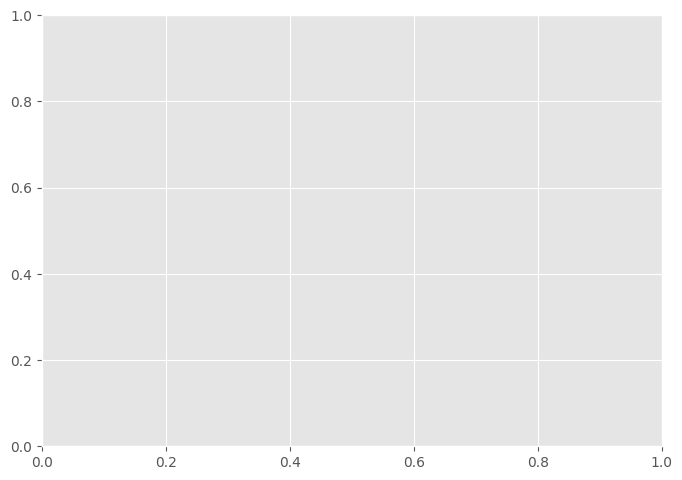

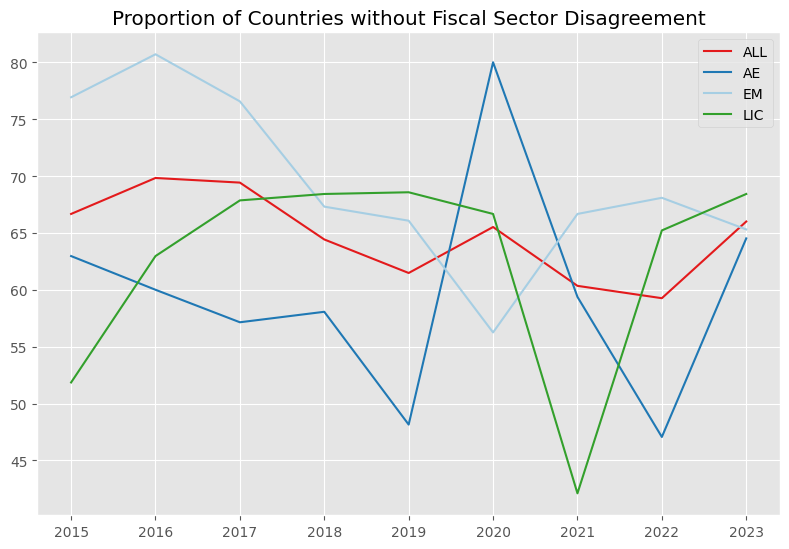

In [69]:
plt.rcParams['figure.figsize'] = (8,5.6)
fig, ax = plt.subplots()

df_temp = ((df_sector.set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()*100).rename(columns={'agreement_general_gpt_ft': 'ALL'})
for c in ['AE', 'EMDE', 'LIC']:
    df_temp = df_temp.merge((df_sector[df_sector['Classification']==c+'s'].set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()*100, left_index=True, right_index=True, how='outer').rename(columns={'agreement_general_gpt_ft': c})
ax = df_temp.plot(color=[colors_cate[4]]+colors_cate)

# y = ((df_sector[df_sector['Classification']=='LICs'].set_index('year')['agreement_general_gpt_ft']!='disagreement exists').reset_index().groupby('year').mean()['agreement_general_gpt_ft']*100).values
# y = np.array(y[:5].tolist()+[np.nan]+y[5:].tolist())
# x = np.array(range(2015, 2024))
# mask = np.isfinite(y)
# line, = ax.plot(x[mask],y[mask], ls="--", color=colors_cate[2],label='_nolegend_')
# ax.plot(x,y, color=colors_cate[2])

plt.title('Proportion of Countries without Fiscal Sector Disagreement')
plt.ylabel('')
plt.xlabel('')
plt.legend( ['ALL','AE', 'EM', 'LIC'])
# plt.ylim(-5, 100)
plt.tight_layout()

In [70]:
area_dict = {'economic fundamentals': 'economic assessment', 'public sector payroll': 'government expenditure', 'inflation impact from spending': 'government expenditure', 'external balance': 'economic assessment', 'fiscal space': 'government debt & financing', 'public investment multiplier':'government expenditure', 'capital expenditure':'fiscal expenditure', 'fiscal targets':'medium-term fiscal stance', 'inflationary pressures':'economic assessment','long-term debt & financing':
            'government debt & financing', 'fiscal multiplier estimation': 'economic assessment'}
df_sector['disagreement_areas_general_gpt_ft_revised'] = df_sector['disagreement_areas_general_gpt_ft']
for area in area_dict:
    df_sector['disagreement_areas_general_gpt_ft_revised'] = df_sector['disagreement_areas_general_gpt_ft_revised'].apply(lambda x: '|'.join(x).replace(area, area_dict[area]).replace('||','|').strip('|').split('|') if x!=[] else [])


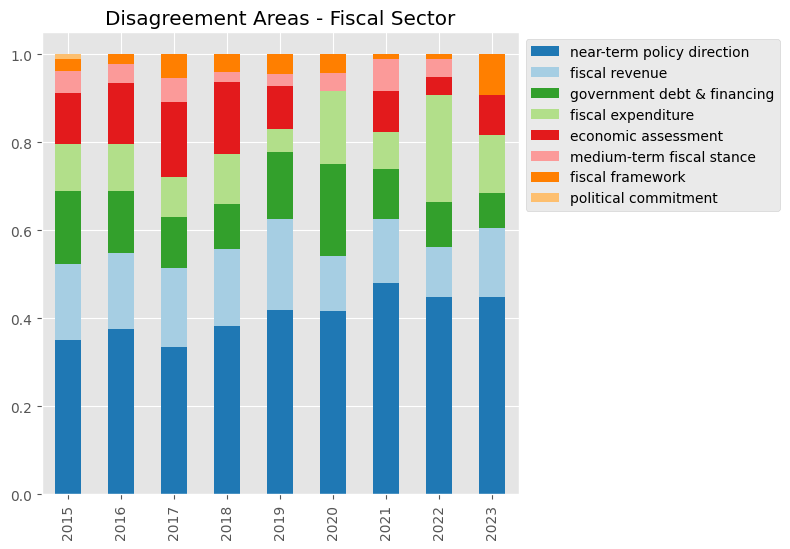

In [71]:
df_temp = pd.DataFrame(itertools.chain.from_iterable(df_sector['disagreement_areas_general_gpt_ft_revised']))
index_l = df_temp[0].value_counts().index
df_temp['year'] = list(itertools.chain.from_iterable(df_sector.apply(lambda x: [x['year']]*len(x['disagreement_areas_general_gpt_ft_revised']), axis=1)))
df_temp = df_temp.groupby('year')[0].value_counts().reset_index().rename(columns={0:'areas'})
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['areas'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[index_l]
ax = pivot.plot.bar(stacked=True, color=colors_cate)
ax.set_title('Disagreement Areas - Fiscal Sector')
plt.legend(index_l, loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

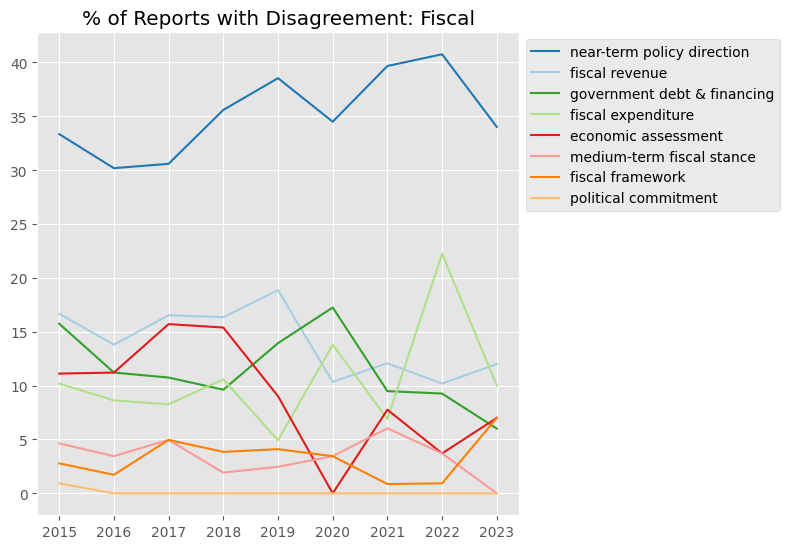

In [73]:
df_temp = pd.DataFrame(itertools.chain.from_iterable(df_sector['disagreement_areas_general_gpt_ft_revised']))
index_l = df_temp[0].value_counts().index
df_temp['year'] = list(itertools.chain.from_iterable(df_sector.apply(lambda x: [x['year']]*len(x['disagreement_areas_general_gpt_ft_revised']), axis=1)))
df_temp = df_temp.groupby('year')[0].value_counts().reset_index().rename(columns={0:'areas'})
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['areas'], values='count').fillna(0)
pivot = (pivot.T/df_sector.groupby('year').count()['country']).T # pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[index_l]

ax = (pivot*100).plot(color=colors_cate)
ax.set_title('% of Reports with Disagreement: Fiscal')
plt.legend(['near-term policy direction', 'fiscal revenue','government debt & financing','fiscal expenditure',
       'economic assessment', 'medium-term fiscal stance',
       'fiscal framework', 'political commitment'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
# plt.ylim(-5, 100)
plt.tight_layout()

Text(0, 0.5, '')

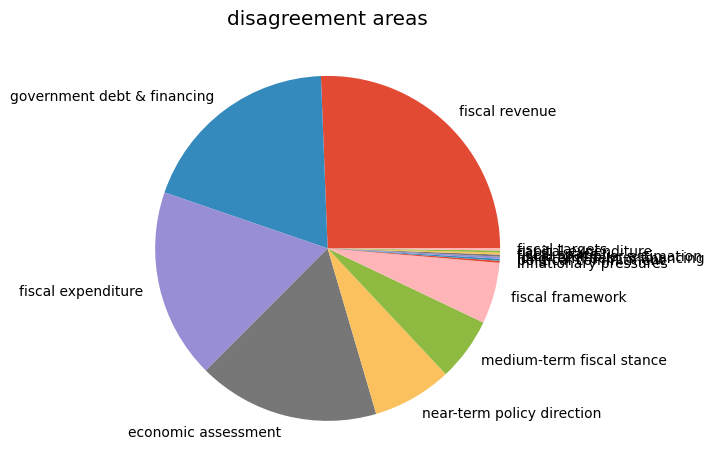

In [74]:
pd.DataFrame(itertools.chain.from_iterable(df_sector['disagreement_areas_gpt_ft'].apply(lambda x: x[0].split('; ') if len(x)>0 and '; ' in x[0] else x)))[0].value_counts().plot.pie()
plt.title('disagreement areas')
plt.ylabel('')

Text(0.5, 0, '')

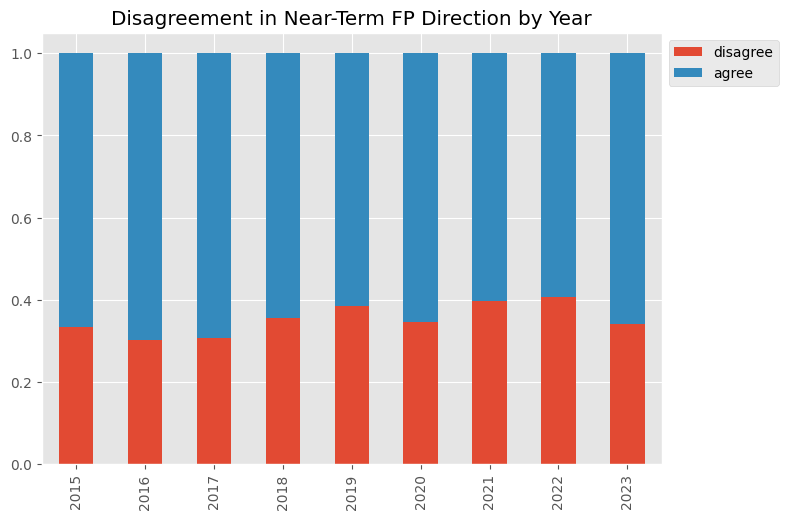

In [75]:
df_temp = df_sector[df_sector['agreement_stance_near_term_gpt_ft']!='irrelevant'].groupby('year')['agreement_stance_near_term_gpt_ft'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['agreement_stance_near_term_gpt_ft'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
# pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'irrelevant', 'loosening bias', 'loosening']]
pivot = pivot[['disagreement exists', 'mostly agree']]
ax = pivot.plot.bar(stacked=True)
ax.set_title('Disagreement in Near-Term FP Direction by Year')
plt.legend(['disagree', 'agree'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')

In [78]:
plt.rcParams['figure.figsize'] = (8,5.6)
df_temp = df_sector[df_sector['agreement_stance_near_term_gpt_ft_cate2']!='irrelevant'].groupby('year')['agreement_stance_near_term_gpt_ft_cate2'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['agreement_stance_near_term_gpt_ft_cate2'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
# pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'irrelevant', 'loosening bias', 'loosening']]
pivot = pivot[['significantly tighter', 'tighter', 'moderately tighter', 'same', 'moderately looser', 'looser', 'significantly looser']]
ax = pivot.plot.bar(stacked=True, color=colors7)
ax.set_title('IMF Advice Compared to Authorities\' Fiscal Policy Direction by Year')
plt.legend(['significantly tighter', 'tighter', 'moderately tighter', 'same', 'moderately looser', 'looser', 'significantly looser'], loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

KeyError: "['tighter'] not in index"

In [79]:
df_temp = df_sector[df_sector['stance_near_term_gpt_ft_buff'].apply(lambda x: x not in ['irrelevant'])].groupby('year')['stance_near_term_gpt_ft_buff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['stance_near_term_gpt_ft_buff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors6)
# ax.set_title('Staff\'s Policy Advice by Year')
ax.set_title('Authorities\' Fiscal Policy Direction by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

KeyError: "['no change', 'unclear'] not in index"

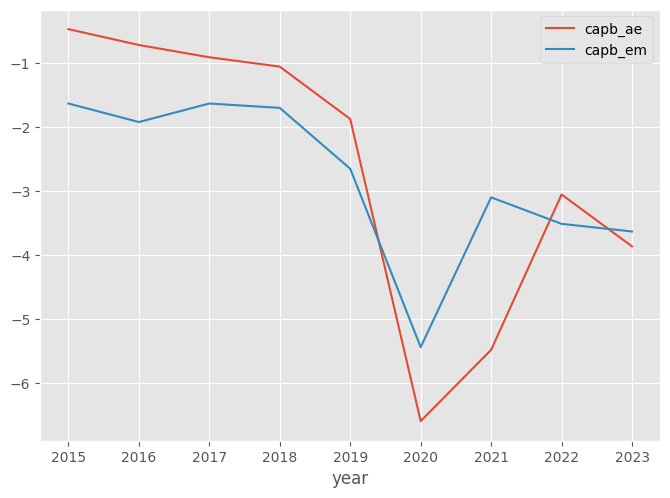

In [80]:
df_sector.groupby('year')[['capb_ae', 'capb_emde']].mean().plot()
plt.legend(['capb_ae', 'capb_em'])
plt.rcParams['figure.figsize'] = (10,3)

In [81]:
df_temp = df_sector[df_sector['stance_near_term_gpt_ft_staff'].apply(lambda x: x not in ['irrelevant'])].groupby('year')['stance_near_term_gpt_ft_staff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['stance_near_term_gpt_ft_staff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors6)
ax.set_title('Staff\'s Fiscal Policy Advice by Year')
# ax.set_title('Authorities\' Policy Direction by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')
plt.tight_layout()

KeyError: "['no change', 'unclear'] not in index"

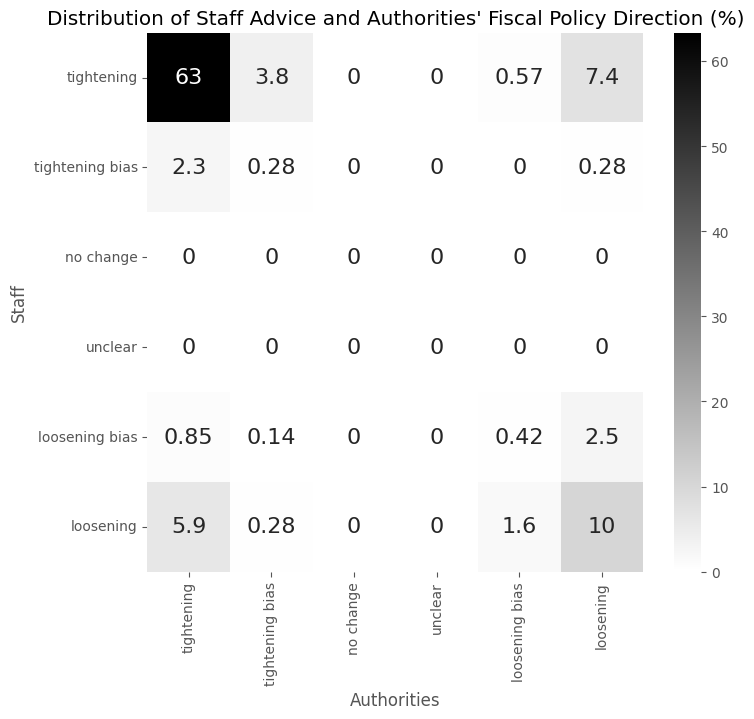

<Figure size 800x700 with 0 Axes>

In [82]:
plt.rcParams['figure.figsize'] = (8,7)
labels = ['tightening', 'tightening bias', 'no change', 'unclear', 'loosening bias', 'loosening']
cm = confusion_matrix(df_sector[df_sector['stance_near_term_gpt_ft_staff'].apply(lambda x: x not in ['irrelevant'])]['stance_near_term_gpt_ft_staff'], df_sector[df_sector['stance_near_term_gpt_ft_buff'].apply(lambda x: x not in ['irrelevant'])]['stance_near_term_gpt_ft_buff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Authorities')
plt.ylabel('Staff')
plt.title('Distribution of Staff Advice and Authorities\' Fiscal Policy Direction (%)')
plt.yticks(rotation='horizontal')
plt.show()
plt.tight_layout()

Policy Mix

In [83]:
df_sector = df_documents[(df_documents['monetary_sample'])&(~df_documents['mon_agreement_gpt_ft'].isna())&(~df_documents['fis_agreement_gpt_ft'].isna())]

In [84]:
df_sector['year'] = df_sector['year'].apply(lambda x: int(x))

In [85]:
df_sector = df_sector[(df_sector['mon_stance_future_gpt_ft_staff']!='irrelevant')&(df_sector['fis_stance_near_term_gpt_ft_staff']!='irrelevant')]
df_sector['mon_stance_future_gpt_ft_staff'] = df_sector['mon_stance_future_gpt_ft_staff'].apply(lambda x: 'no change / unclear' if x in ['unclear', 'no change', 'gradual normalization'] else x)
df_sector['fis_stance_near_term_gpt_ft_staff'] = df_sector['fis_stance_near_term_gpt_ft_staff'].apply(lambda x: 'no change / unclear' if x in ['unclear', 'no change'] else x)

df_sector['policy_mix_staff'] = df_sector.apply(lambda x: 'MtFt' if 'tightening' in x['mon_stance_future_gpt_ft_staff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MtFn' if 'tightening' in x['mon_stance_future_gpt_ft_staff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MtFl' if 'tightening' in x['mon_stance_future_gpt_ft_staff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MlFt' if 'loosening' in x['mon_stance_future_gpt_ft_staff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MlFn' if 'loosening' in x['mon_stance_future_gpt_ft_staff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MlFl' if 'loosening' in x['mon_stance_future_gpt_ft_staff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MnFt' if 'no change / unclear' in x['mon_stance_future_gpt_ft_staff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MnFn' if 'no change / unclear' in x['mon_stance_future_gpt_ft_staff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_staff'] else
                                                'MnFl' if 'no change / unclear' in x['mon_stance_future_gpt_ft_staff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_staff'] else np.nan
                                                , axis=1)

df_sector = df_sector[(df_sector['mon_stance_future_gpt_ft_buff']!='irrelevant')&(df_sector['fis_stance_near_term_gpt_ft_buff']!='irrelevant')]
df_sector['mon_stance_future_gpt_ft_buff'] = df_sector['mon_stance_future_gpt_ft_buff'].apply(lambda x: 'no change / unclear' if x in ['unclear', 'no change', 'gradual normalization'] else x)
df_sector['fis_stance_near_term_gpt_ft_buff'] = df_sector['fis_stance_near_term_gpt_ft_buff'].apply(lambda x: 'no change / unclear' if x in ['unclear', 'no change'] else x)

df_sector['policy_mix_buff'] = df_sector.apply(lambda x: 'MtFt' if 'tightening' in x['mon_stance_future_gpt_ft_buff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MtFn' if 'tightening' in x['mon_stance_future_gpt_ft_buff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MtFl' if 'tightening' in x['mon_stance_future_gpt_ft_buff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MlFt' if 'loosening' in x['mon_stance_future_gpt_ft_buff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MlFn' if 'loosening' in x['mon_stance_future_gpt_ft_buff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MlFl' if 'loosening' in x['mon_stance_future_gpt_ft_buff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MnFt' if 'no change / unclear' in x['mon_stance_future_gpt_ft_buff'] and 'tightening' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MnFn' if 'no change / unclear' in x['mon_stance_future_gpt_ft_buff'] and 'no change / unclear' in x['fis_stance_near_term_gpt_ft_buff'] else
                                                'MnFl' if 'no change / unclear' in x['mon_stance_future_gpt_ft_buff'] and 'loosening' in x['fis_stance_near_term_gpt_ft_buff'] else np.nan
                                                , axis=1)

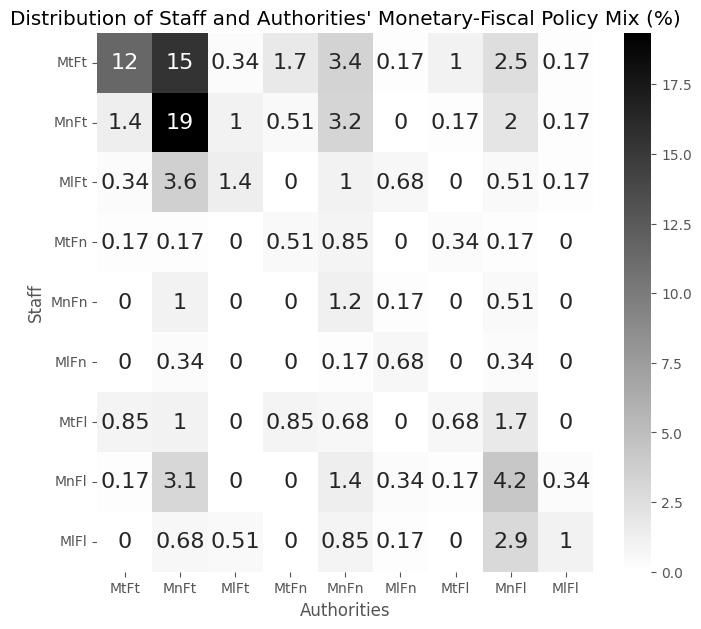

In [86]:
labels = ['MtFt', 'MnFt', 'MlFt', 'MtFn', 'MnFn', 'MlFn', 'MtFl', 'MnFl', 'MlFl']
cm = confusion_matrix(df_sector['policy_mix_staff'], df_sector['policy_mix_buff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Authorities')
plt.ylabel('Staff')
plt.title('Distribution of Staff and Authorities\' Monetary-Fiscal Policy Mix (%)')
plt.yticks(rotation='horizontal')
plt.show()


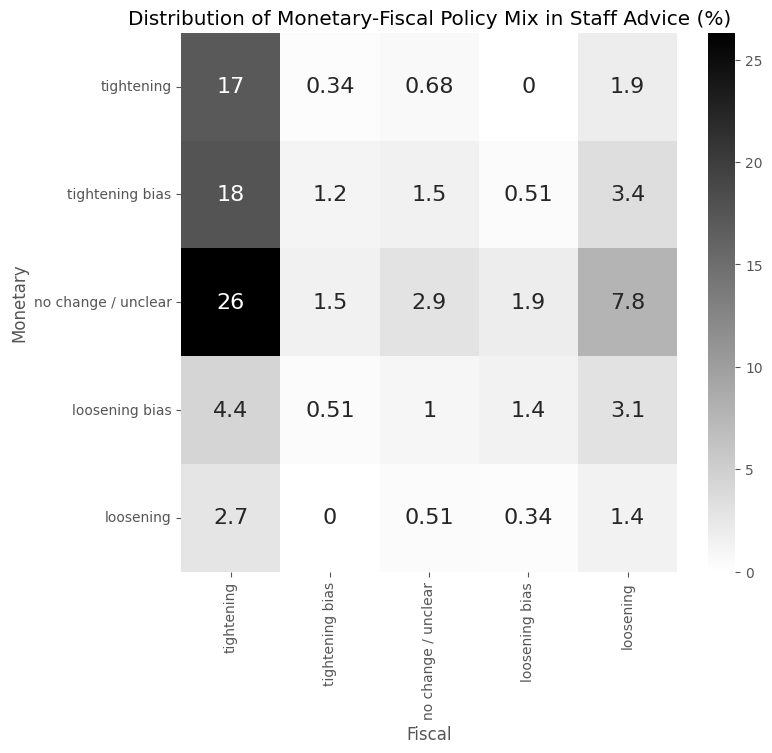

<Figure size 800x700 with 0 Axes>

In [87]:
labels = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']


cm = confusion_matrix(df_sector['mon_stance_future_gpt_ft_staff'], df_sector['fis_stance_near_term_gpt_ft_staff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Fiscal')
plt.ylabel('Monetary')
plt.title('Distribution of Monetary-Fiscal Policy Mix in Staff Advice (%)')
plt.yticks(rotation='horizontal')
plt.show()
plt.tight_layout()

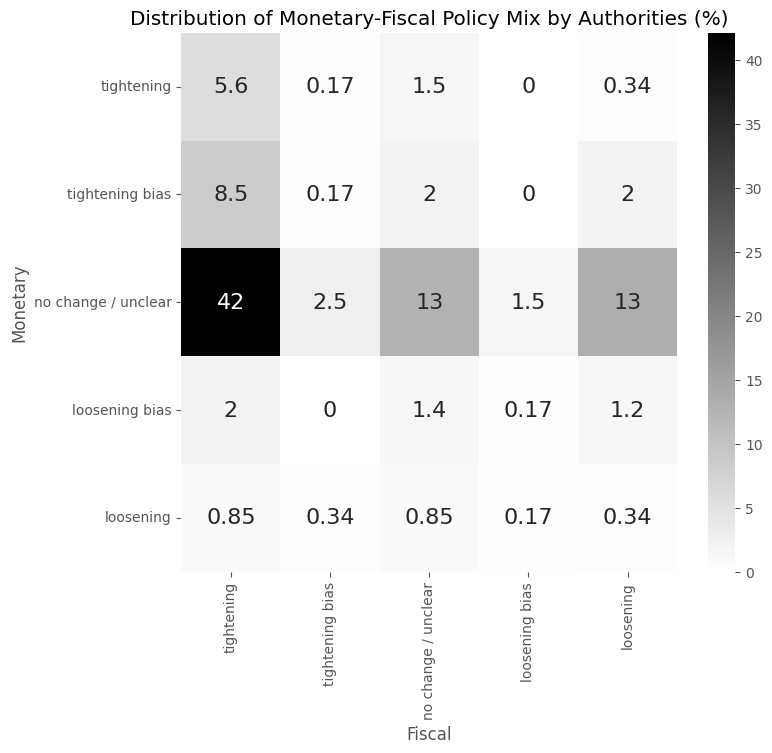

<Figure size 800x700 with 0 Axes>

In [88]:
labels = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']


cm = confusion_matrix(df_sector['mon_stance_future_gpt_ft_buff'], df_sector['fis_stance_near_term_gpt_ft_buff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Fiscal')
plt.ylabel('Monetary')
plt.title('Distribution of Monetary-Fiscal Policy Mix by Authorities (%)')
plt.yticks(rotation='horizontal')
plt.show()
plt.tight_layout()

Text(0.5, 0, '')

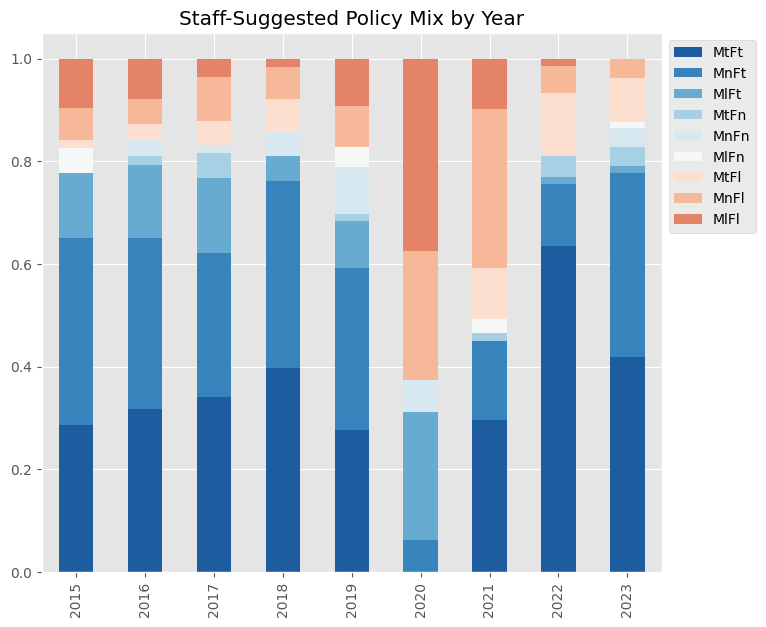

In [89]:
df_temp = df_sector.groupby('year')['policy_mix_staff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['policy_mix_staff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['MtFt', 'MnFt', 'MlFt', 'MtFn', 'MnFn', 'MlFn', 'MtFl', 'MnFl', 'MlFl']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors11)
ax.set_title('Staff-Suggested Policy Mix by Year')
# ax.set_title('Authorities\' Policy Direction by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')

Text(0.5, 0, '')

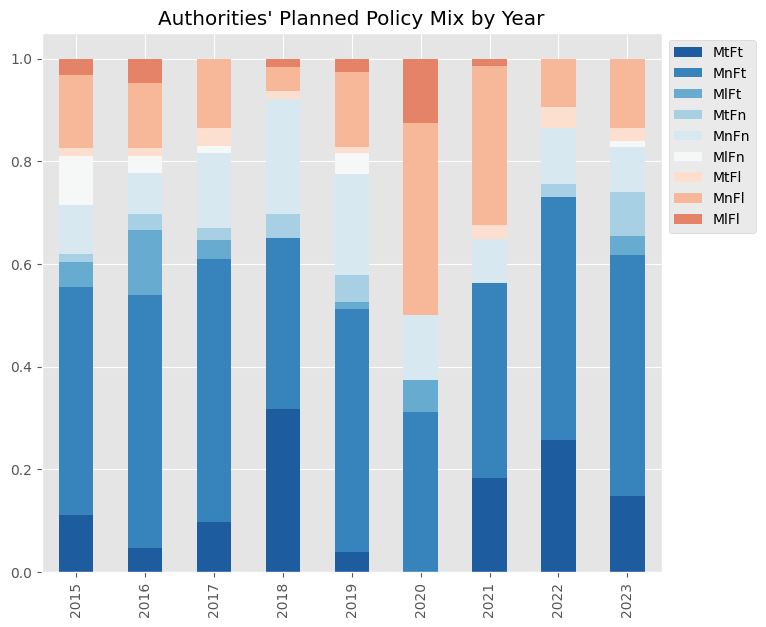

In [90]:
df_temp = df_sector.groupby('year')['policy_mix_buff'].value_counts().reset_index()
pivot = pd.pivot_table(data=df_temp, index=['year'], columns=['policy_mix_buff'], values='count').fillna(0)
pivot = (pivot.T/pivot.T.sum()).T
pivot = pivot[['MtFt', 'MnFt', 'MlFt', 'MtFn', 'MnFn', 'MlFn', 'MtFl', 'MnFl', 'MlFl']]
# pivot = pivot[['restrictive', 'neutral', 'unclear', 'irrelevant', 'accommodative']]
ax = pivot.plot.bar(stacked=True, color=colors11)
ax.set_title('Authorities\' Planned Policy Mix by Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1)
plt.xlabel('')

In [91]:
# compare with CPA
cpa_dict = {'Stay on hold':'no change / unclear', 'Stay on hold, tightening bias':'tightening bias', 'Tighten moderately':'tightening',
       'Tighten':'tightening', 'Stay on hold, loosening bias':'loosening bias', 'Loosen moderately':'loosening',
       'Loosen':'loosening'}

df['mp_future_staff_bm_m'] = df['mp_future_staff_bm'].apply(lambda x: cpa_dict[x] if x in cpa_dict else x)
df['fp_future_staff_bm_m'] = df['fp_future_staff_bm'].apply(lambda x: cpa_dict[x] if x in cpa_dict else x)

df['mp_future_staff_m'] = df['mp_future_staff'].apply(lambda x: cpa_dict[x] if x in cpa_dict else x)
df['fp_future_staff_m'] = df['fp_future_staff'].apply(lambda x: cpa_dict[x] if x in cpa_dict else x)

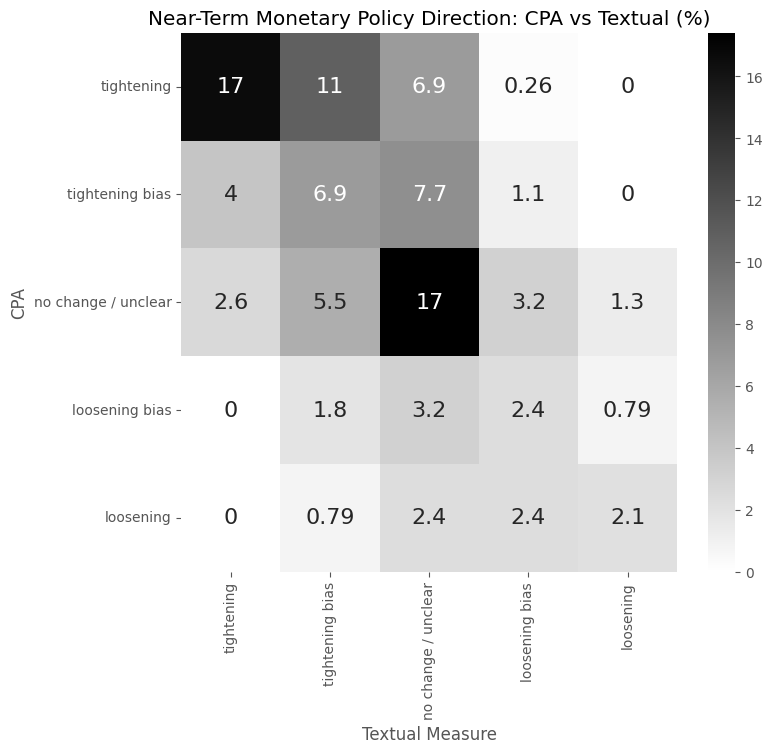

<Figure size 800x700 with 0 Axes>

In [92]:
labels = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']
df_temp = df[(df['mp_future_staff_m']==df['mp_future_staff_m'])&(df['mon_stance_future_gpt_ft_staff']==df['mon_stance_future_gpt_ft_staff'])]
cm = confusion_matrix(df_temp['mp_future_staff_m'], df_temp['mon_stance_future_gpt_ft_staff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Textual Measure')
plt.ylabel('CPA')
plt.title('Near-Term Monetary Policy Direction: CPA vs Textual (%)')
plt.yticks(rotation='horizontal')
plt.show()
plt.tight_layout()

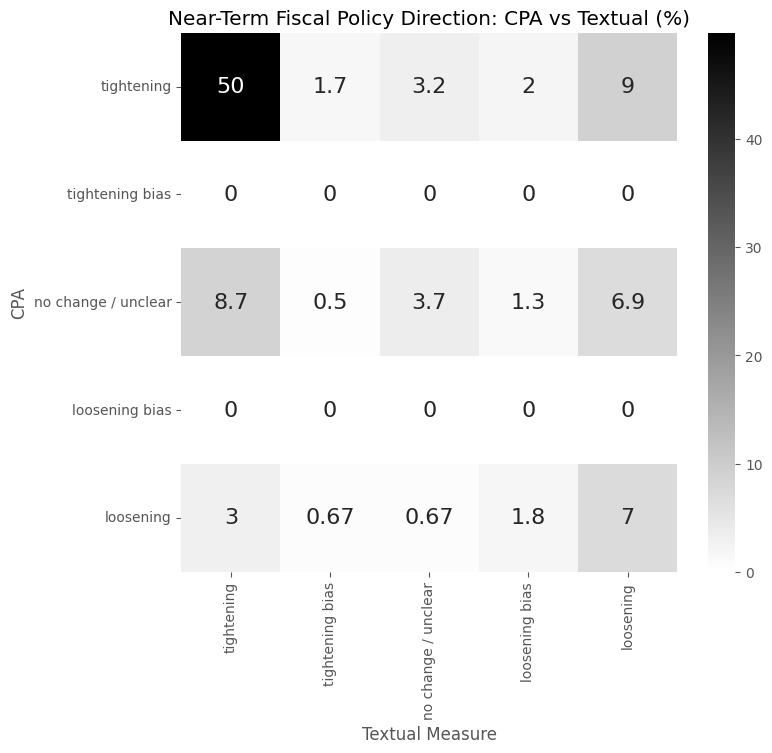

<Figure size 800x700 with 0 Axes>

In [93]:
labels = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']
df_temp = df[(df['fp_future_staff_bm_m']==df['fp_future_staff_bm_m'])&(df['fis_stance_near_term_gpt_ft_staff']==df['fis_stance_near_term_gpt_ft_staff'])]
cm = confusion_matrix(df_temp['fp_future_staff_bm_m'], df_temp['fis_stance_near_term_gpt_ft_staff'], labels=labels)
df_cm = pd.DataFrame(cm, labels, labels)
df_cm = df_cm/df_cm.sum().sum()*100
# sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap='binary')
plt.xlabel('Textual Measure')
plt.ylabel('CPA')
plt.title('Near-Term Fiscal Policy Direction: CPA vs Textual (%)')
plt.yticks(rotation='horizontal')
plt.show()
plt.tight_layout()

In [94]:
confusion_matrix(df['mp_future_staff_bm_m'], df['mon_stance_future_gpt_ft_staff'])

ValueError: unknown is not supported

In [95]:
df['mon_stance_future_gpt_ft_staff'].value_counts()

mon_stance_future_gpt_ft_staff
no change / unclear    286
tightening bias        161
tightening             126
loosening bias          67
loosening               30
irrelevant              16
Name: count, dtype: int64